In [59]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

In [60]:
PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import trace_st as tst  # noqa: E402

In [61]:
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D

import copy

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [62]:
def load_json(path):
    path = Path(path)
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def load_jsonl(path):
    path = Path(path)
    if not path.exists():
        return []
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for i, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except Exception:
                print(f"Warning: could not parse line {i} in {path}")
    return rows


def safe_read_csv(path):
    path = Path(path)
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()


def summarize_table(name, df):
    print(f"{name}: shape={df.shape}")
    if len(df) > 0:
        print(f"  columns={list(df.columns[:12])}" + (" ..." if len(df.columns) > 12 else ""))

In [63]:
def run_one_track(full_data, params, date_end):
    out = tst.trajectory.run_track(
        full_data,
        params,
        date_end=date_end,
        return_debug=True,
        return_cluster_summaries=False,
    )
    centers = np.asarray(out["centers"], dtype=float)
    parents = np.asarray(out["parents"], dtype=int)
    return centers, parents, out


In [64]:
def infer_lat_lon_names(da):
    lat_name = "lat" if "lat" in da.coords else "latitude"
    lon_name = "lon" if "lon" in da.coords else "longitude"
    return lat_name, lon_name


def lon0360_to_m180_180(lon):
    lon = np.asarray(lon, dtype=float) % 360.0
    return ((lon + 180.0) % 360.0) - 180.0


def density_for_plotting_m180_180(dens_da):
    lon_name = "lon" if "lon" in dens_da.coords else "longitude"
    return dens_da.assign_coords(
        {lon_name: (((dens_da[lon_name] + 180) % 360) - 180)}
    ).sortby(lon_name)


In [65]:
def compute_density_for_var(full_data_run, ensemble_results, box_size_deg, var_name, normalize=False):
    return compute_trajectory_box_density(
        ensemble_results=ensemble_results,
        full_data_run=full_data_run,
        box_size_deg=box_size_deg,
        selected_var=var_name,
        normalize=normalize,
        skip_step0=True,
    )

def _box_mask_for_center(lat_vals, lon_vals0360, center_lat, center_lon0360, box_size_deg):
    """
    Return boolean mask [lat, lon] for a lat-lon aligned box centered at
    (center_lat, center_lon0360). Handles dateline wrap in 0..360 coordinates.
    """
    if np.isscalar(box_size_deg):
        dlat = dlon = float(box_size_deg)
    else:
        dlat, dlon = map(float, box_size_deg)

    half_lat = dlat / 2.0
    half_lon = dlon / 2.0

    lat_min = center_lat - half_lat
    lat_max = center_lat + half_lat

    lon_min = (center_lon0360 - half_lon) % 360.0
    lon_max = (center_lon0360 + half_lon) % 360.0

    lat_mask = (lat_vals >= lat_min) & (lat_vals <= lat_max)

    if lon_min <= lon_max:
        lon_mask = (lon_vals0360 >= lon_min) & (lon_vals0360 <= lon_max)
    else:
        lon_mask = (lon_vals0360 >= lon_min) | (lon_vals0360 <= lon_max)

    return lat_mask[:, None] & lon_mask[None, :]


def compute_trajectory_box_density(
    ensemble_results,
    full_data_run,
    box_size_deg,
    selected_var=None,
    normalize=False,
    skip_step0=True,
):
    """
    Compute density = number of times an ensemble box footprint passes over each grid cell.
    """
    lat_name, lon_name = infer_lat_lon_names(full_data_run)
    lat_vals = np.asarray(full_data_run[lat_name].values, dtype=float)
    lon_vals = np.asarray(full_data_run[lon_name].values, dtype=float) % 360.0

    dens = np.zeros((len(lat_vals), len(lon_vals)), dtype=np.float64)

    var_names = list(full_data_run["var"].values) if "var" in full_data_run.coords else None
    selected_parent_index = None

    if isinstance(selected_var, str):
        if var_names is None:
            raise ValueError("selected_var given as string, but full_data_run has no 'var' coord.")
        if selected_var not in var_names:
            raise ValueError(f"selected_var='{selected_var}' not found in var names: {var_names}")
        selected_parent_index = var_names.index(selected_var) + 1
    elif isinstance(selected_var, (int, np.integer)):
        selected_parent_index = int(selected_var)
    elif selected_var is not None:
        raise ValueError("selected_var must be None, int, or str.")

    start_idx = 1 if skip_step0 else 0

    for res in ensemble_results:
        centers = np.asarray(res["centers"], dtype=float)
        parents = np.asarray(res["parents"], dtype=int)

        for i in range(start_idx, len(centers)):
            if selected_parent_index is not None and parents[i] != selected_parent_index:
                continue

            c_lat = float(centers[i, 0])
            c_lon0360 = float(centers[i, 1]) % 360.0

            mask = _box_mask_for_center(
                lat_vals=lat_vals,
                lon_vals0360=lon_vals,
                center_lat=c_lat,
                center_lon0360=c_lon0360,
                box_size_deg=box_size_deg,
            )
            dens += mask.astype(np.float64)

    if normalize and np.nanmax(dens) > 0:
        dens = dens / np.nanmax(dens)

    dens_da = xr.DataArray(
        dens,
        coords={lat_name: full_data_run[lat_name], lon_name: full_data_run[lon_name]},
        dims=(lat_name, lon_name),
        name="trajectory_box_density",
    )
    return dens_da


def choose_contour_steps(n_steps, every=2):
    """
    Choose step indices for contours. Always include first and last.
    """
    idx = list(range(0, n_steps, every))
    if (n_steps - 1) not in idx:
        idx.append(n_steps - 1)
    return np.array(sorted(set(idx)), dtype=int)


def get_field_at_track_step(full_data_run, var_name, date_end, step_idx):
    """
    Returns the 2D field for `var_name` at the trajectory time corresponding
    to `step_idx` days before `date_end`.
    """
    target_time = pd.Timestamp(date_end) - pd.Timedelta(days=int(step_idx))
    da = full_data_run.sel(var=var_name).sel(time=target_time, method="nearest")
    return da

In [66]:
def plot_trace_st_debby_4panel(
    full_data_run,
    centers_det,
    parents_det,
    ensemble_results,
    *,
    date_end,
    box_size_deg,
    panel_vars,
    panel_titles=None,
    contour_every=24,
    contour_level_std=2.0,
    contour_mode="both",           # "positive", "negative", "both", or dict by variable
    timeres_hours=1.0,
    extent=(-50, 40, 0, 40),
    density_cmap="hot_r",
    track_cmap="plasma",
    density_alpha=1.0,
    contour_linewidth=1.0,
    track_linewidth=1.3,
    point_size=32,
    scatter_stride=6,
    ensemble_linewidth=0.8,
    ensemble_alpha=0.20,
    ensemble_markersize=10,
    normalize_density=False,
    density_percentile_cap=99.0,
    event_lon=None,
    event_lat=None,
    event_label="Target",
    storm_lon=None,
    storm_lat=None,
    storm_hours_back=None,
    storm_marker="X",
    storm_marker_size=70,
    storm_stride=1,
):
    """
    Debby figure styled to match the Pinatubo figure:
      A: ensemble spaghetti
      B/C/D: variable-specific density + contours + deterministic trajectory
    """
    lat_name, lon_name = infer_lat_lon_names(full_data_run)

    centers = np.asarray(centers_det, dtype=float)
    parents = np.asarray(parents_det, dtype=int)

    det_lats = centers[:, 0]
    det_lons = lon0360_to_m180_180(centers[:, 1] % 360.0)

    n_steps = len(centers)
    hours_back = np.arange(n_steps) * float(timeres_hours)

    var_names = list(full_data_run["var"].values)
    p0 = np.clip(parents - 1, 0, len(var_names) - 1)
    parent_labels = np.array([var_names[i] for i in p0])

    marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
    marker_map = {name: marker_cycle[i % len(marker_cycle)] for i, name in enumerate(var_names)}

    lag_cmap = plt.get_cmap(track_cmap)
    lag_norm = mpl.colors.Normalize(
        vmin=float(np.nanmin(hours_back)),
        vmax=float(np.nanmax(hours_back)),
    )

    if panel_titles is None:
        panel_titles = {
            "Tb": "Brightness temperature",
            "vo": "Mid-level vorticity",
            "precip": "Precipitation",
        }

    # -----------------------------
    # Precompute densities for B/C/D
    # -----------------------------
    dens_plot_list = []
    vmax_candidates = []
    
    ensemble_for_density = drop_initial_steps_from_ensemble(
        ensemble_results,
        n_skip=1   # <-- change this if needed
    )
    for v in panel_vars:
        dens = compute_density_for_var(
            full_data_run=full_data_run,
            ensemble_results=ensemble_for_density,
            box_size_deg=box_size_deg,
            var_name=v,
            normalize=normalize_density,
        )
        dens_plot = density_for_plotting_m180_180(dens)
        dens_plot_list.append(dens_plot)

        vals = np.asarray(dens_plot.values, dtype=float)
        vals = vals[np.isfinite(vals)]
        if vals.size:
            vmax_candidates.append(np.percentile(vals, density_percentile_cap))

    density_vmax = max(vmax_candidates) if len(vmax_candidates) else 1.0
    density_vmin = 0.0

    # -----------------------------
    # Figure and axes (same feel as Pinatubo)
    # -----------------------------
    proj = ccrs.PlateCarree()
    fig, axes = plt.subplots(
        2, 2,
        figsize=(14, 5.5),
        subplot_kw=dict(projection=proj),
        constrained_layout=False,
    )
    axes = axes.ravel()

    panel_letters = ["A", "B", "C", "D"]

    # ==================================================
    # Panel A: ensemble spaghetti
    # ==================================================
    ax = axes[0]
    ax.set_extent(extent, crs=proj)
    ax.set_facecolor("white")
    ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=3)

    gl = ax.gridlines(draw_labels=False, linewidth=0.35, alpha=0.35, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    for res in ensemble_results:
        centers_ens = np.asarray(res["centers"], dtype=float)
        parents_ens = np.asarray(res["parents"], dtype=int)

        lats_ens = centers_ens[:, 0]
        lons_ens = lon0360_to_m180_180(centers_ens[:, 1] % 360.0)

        steps_ens = np.arange(len(lats_ens))
        hours_back_ens = steps_ens * float(timeres_hours)

        ax.plot(
            lons_ens,
            lats_ens,
            "-",
            color="k",
            linewidth=ensemble_linewidth,
            alpha=ensemble_alpha,
            transform=proj,
            zorder=2,
        )

        p0_ens = np.clip(parents_ens - 1, 0, len(var_names) - 1)
        parent_labels_ens = np.array([var_names[i] for i in p0_ens])

        for vname in var_names:
            mask = parent_labels_ens == vname
            if not np.any(mask):
                continue

            idx = np.where(mask)[0][::scatter_stride]

            ax.scatter(
                lons_ens[idx],
                lats_ens[idx],
                c=hours_back_ens[idx],
                cmap=lag_cmap,
                norm=lag_norm,
                marker=marker_map[vname],
                s=ensemble_markersize,
                alpha=0.55,
                edgecolor="none",
                transform=proj,
                zorder=3,
            )

    # if event_lon is not None and event_lat is not None:
    #     ax.scatter(
    #         event_lon, event_lat,
    #         marker="^",
    #         s=160,
    #         color="red",
    #         edgecolor="k",
    #         linewidth=0.8,
    #         transform=proj,
    #         zorder=7,
    #     )
    # Observed Debby track
    if storm_lon is not None and storm_lat is not None and storm_hours_back is not None:
        idx_storm = np.arange(len(storm_lon))[::storm_stride]

        ax.scatter(
            np.asarray(storm_lon)[idx_storm],
            np.asarray(storm_lat)[idx_storm],
            c=np.asarray(storm_hours_back)[idx_storm],
            cmap=lag_cmap,
            norm=lag_norm,
            marker=storm_marker,
            s=storm_marker_size,
            edgecolor="k",
            linewidth=0.4,
            transform=proj,
            zorder=6,
        )
        
    ax.set_title(
        f"{panel_letters[0]}. Ensemble of trajectories",
        loc="left",
        fontsize=14,
        fontweight="bold",
    )

    # ==================================================
    # Panels B/C/D: density + contours + deterministic
    # ==================================================
    density_mappable = None
    contour_steps = choose_contour_steps(n_steps, contour_every)

    for ax, vname, dens_plot, letter in zip(axes[1:], panel_vars, dens_plot_list, panel_letters[1:]):
        ax.set_extent(extent, crs=proj)
        ax.set_facecolor("white")
        ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="none", zorder=0)
        ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=3)

        gl = ax.gridlines(draw_labels=False, linewidth=0.35, alpha=0.35, linestyle="--")
        gl.top_labels = False
        gl.right_labels = False

        lonp = np.asarray(dens_plot[lon_name].values, dtype=float)
        latp = np.asarray(dens_plot[lat_name].values, dtype=float)
        densv = np.asarray(dens_plot.values, dtype=float)

        mesh = ax.pcolormesh(
            lonp,
            latp,
            densv,
            transform=proj,
            shading="auto",
            cmap=density_cmap,
            vmin=density_vmin,
            vmax=density_vmax,
            alpha=density_alpha,
            zorder=1,
            rasterized=True
        )
        density_mappable = mesh

        # variable-specific contour mode support
        if isinstance(contour_mode, dict):
            this_mode = contour_mode.get(vname, "positive")
        else:
            this_mode = contour_mode

        for step_idx in contour_steps:
            target_time = pd.Timestamp(date_end) - pd.Timedelta(hours=int(step_idx))
            da2d = full_data_run.sel(var=vname).sel(time=target_time, method="nearest")

            da2d_plot = da2d.assign_coords(
                {lon_name: (((da2d[lon_name] + 180) % 360) - 180)}
            ).sortby(lon_name)

            lons_c = np.asarray(da2d_plot[lon_name].values, dtype=float)
            lats_c = np.asarray(da2d_plot[lat_name].values, dtype=float)
            vals_c = np.asarray(da2d_plot.values, dtype=float)

            contour_color = lag_cmap(lag_norm(hours_back[step_idx]))

            if this_mode == "positive":
                levels = [contour_level_std]
            elif this_mode == "negative":
                levels = [-contour_level_std]
            elif this_mode == "both":
                levels = [-contour_level_std, contour_level_std]
            else:
                raise ValueError("contour_mode must be 'positive', 'negative', 'both', or dict")

            try:
                ax.contour(
                    lons_c,
                    lats_c,
                    vals_c,
                    levels=levels,
                    colors=[contour_color] * len(levels),
                    linewidths=contour_linewidth,
                    alpha=0.90,
                    transform=proj,
                    zorder=4,
                )
            except Exception:
                pass

        # deterministic line
        ax.plot(
            det_lons,
            det_lats,
            color="k",
            linewidth=track_linewidth,
            zorder=5,
            transform=proj,
        )
        
        # Observed Debby track
        if storm_lon is not None and storm_lat is not None and storm_hours_back is not None:
            idx_storm = np.arange(len(storm_lon))[::storm_stride]

            ax.scatter(
                np.asarray(storm_lon)[idx_storm],
                np.asarray(storm_lat)[idx_storm],
                c=np.asarray(storm_hours_back)[idx_storm],
                cmap=lag_cmap,
                norm=lag_norm,
                marker=storm_marker,
                s=storm_marker_size,
                edgecolor="k",
                linewidth=0.4,
                zorder=7,
                transform=proj,
            )

        # deterministic points with stride
        for pv in var_names:
            mask = parent_labels == pv
            if not np.any(mask):
                continue

            idx = np.where(mask)[0][::scatter_stride]

            ax.scatter(
                det_lons[idx],
                det_lats[idx],
                c=hours_back[idx],
                cmap=lag_cmap,
                norm=lag_norm,
                s=point_size,
                marker=marker_map[pv],
                edgecolor="k",
                linewidth=0.25,
                zorder=6,
                transform=proj,
            )

        # start
        ax.scatter(
            det_lons[0], det_lats[0],
            s=70,
            marker="o",
            facecolors="white",
            edgecolors="k",
            linewidth=1.0,
            zorder=7,
            transform=proj,
        )

        # end
        ax.scatter(
            det_lons[-1], det_lats[-1],
            s=100,
            marker="*",
            color="gold",
            edgecolor="k",
            linewidth=0.8,
            zorder=7,
            transform=proj,
        )

        # if event_lon is not None and event_lat is not None:
        #     ax.scatter(
        #         event_lon, event_lat,
        #         marker="^",
        #         s=160,
        #         color="red",
        #         edgecolor="k",
        #         linewidth=0.8,
        #         zorder=7,
        #         transform=proj,
        #     )

        ax.set_title(
            f"{letter}. {panel_titles.get(vname, vname)}",
            loc="left",
            fontsize=14,
            fontweight="bold",
        )

    # -----------------------------
    # Legend (same style as Pinatubo)
    # -----------------------------
    legend_handles = [
        Line2D([0], [0], marker=marker_map[v], linestyle="None",
               markerfacecolor="k", markeredgecolor="k",
               markersize=7, label=v)
        for v in var_names
    ]
    legend_handles += [
        # Line2D([0], [0], marker="o", color="white", markeredgecolor="k",
        #        linestyle="None", markersize=8, label="Start"),
        Line2D([0], [0], marker="*", color="gold", markeredgecolor="k",
               linestyle="None", markersize=10, label="End"),
        # Line2D([0], [0], marker="^", color="red", markeredgecolor="k",
        #        linestyle="None", markersize=10, label=event_label),
    ]
    
    legend_handles += [
        Line2D([0], [0], marker="*", color="gold", markeredgecolor="k",
               linestyle="None", markersize=10, label="End"),
        Line2D([0], [0], marker=storm_marker, color="white", markeredgecolor="k",
               linestyle="None", markersize=9, label="Observed track"),
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.24, -0.02),
        ncol=2,
        frameon=True,
        fontsize=10,
        title="Deterministic parent / markers",
        title_fontsize=11,
    )

    # -----------------------------
    # Layout and colorbars (matched to Pinatubo)
    # -----------------------------
    fig.subplots_adjust(left=0.04, right=0.96, top=0.93, bottom=0.16,
                        wspace=0.08, hspace=0.10)

    cax_den = fig.add_axes([0.36, 0.10, 0.25, 0.025])
    cb_den = fig.colorbar(density_mappable, cax=cax_den, orientation="horizontal")
    cb_den.set_label("Trajectory density", fontsize=11)

    sm_lag = mpl.cm.ScalarMappable(norm=lag_norm, cmap=lag_cmap)
    sm_lag.set_array([])
    cax_lag = fig.add_axes([0.63, 0.10, 0.25, 0.025])
    cb_lag = fig.colorbar(sm_lag, cax=cax_lag, orientation="horizontal")
    cb_lag.set_label("Hours back from target date", fontsize=11)

    fig.suptitle(
        "Tropical Storm Debby (2006)",
        fontsize=14,
        fontweight="bold",
        y=1.0,
    )

    return fig, axes

In [67]:


# =========================================================
# Small helpers
# =========================================================

def _accumulate_density_box(density, xs, ys, centers, box_size):
    centers = np.asarray(centers, dtype=float)
    if len(centers) == 0:
        return density

    half = float(box_size) / 2.0
    for yc, xc in centers:
        x0 = xc - half
        x1 = xc + half
        y0 = yc - half
        y1 = yc + half

        xmask = (xs >= x0) & (xs <= x1)
        ymask = (ys >= y0) & (ys <= y1)

        if np.any(xmask) and np.any(ymask):
            density[np.ix_(ymask, xmask)] += 1.0
    return density

def load_bundle_for_trial(trial_id, jobs_df):
    row = jobs_df.loc[jobs_df["trial_id"] == trial_id]
    if len(row) == 0:
        raise ValueError(f"trial_id={trial_id} not found in jobs_df")
    row = row.iloc[0]

    npz_path = Path(row["bundle_npz"])
    json_path = Path(row["bundle_json"])

    if not npz_path.exists():
        raise FileNotFoundError(npz_path)
    if not json_path.exists():
        raise FileNotFoundError(json_path)

    bundle_npz = np.load(npz_path, allow_pickle=True)
    with open(json_path, "r", encoding="utf-8") as f:
        bundle_meta = json.load(f)

    return row, bundle_npz, bundle_meta


def reconstruct_ensemble_from_bundle(bundle_npz):
    centers_pad = bundle_npz["centers"]
    parents_pad = bundle_npz["parents"]
    lengths = bundle_npz["lengths"]
    ok_arr = bundle_npz["ok"]
    member_ids = bundle_npz["member_id"]

    ensemble_results = []
    for i in range(len(lengths)):
        L = int(lengths[i])
        if int(ok_arr[i]) != 1 or L <= 0:
            continue
        ensemble_results.append({
            "member_id": int(member_ids[i]),
            "centers": np.asarray(centers_pad[i, :L, :], dtype=float),
            "parents": np.asarray(parents_pad[i, :L], dtype=int),
        })
    return ensemble_results


def compute_density_for_var_multi(
    full_data_run,
    ensemble_results,
    box_size_deg,
    var_name,
):
    lat_name, lon_name = infer_lat_lon_names(full_data_run)
    ys = np.asarray(full_data_run[lat_name].values, dtype=float)
    xs = np.asarray(full_data_run[lon_name].values, dtype=float)

    var_names = list(full_data_run["var"].values)
    var_to_parent = {v: i + 1 for i, v in enumerate(var_names)}
    parent_id = var_to_parent[var_name]

    density = np.zeros((len(ys), len(xs)), dtype=float)

    for res in ensemble_results:
        centers = np.asarray(res["centers"], dtype=float)
        parents = np.asarray(res["parents"], dtype=int)
        if len(centers) == 0 or len(parents) == 0:
            continue

        mask = parents == parent_id
        if np.any(mask):
            density = _accumulate_density_box(
                density,
                xs,
                ys,
                centers[mask],
                box_size_deg,
            )

    dens_da = xr.DataArray(
        density,
        dims=(lat_name, lon_name),
        coords={lat_name: ys, lon_name: xs},
        name=f"density_{var_name}",
    )
    return dens_da

def plot_trace_st_debby_6panel_multi_trials(
    trial_ids,
    jobs_df,
    members_df,
    full_data_run,
    *,
    date_end,
    run_one_track,
    panel_vars=("Tb", "vo", "precip"),
    panel_titles=None,
    contour_every=48,
    contour_level_std=100,
    contour_mode=None,
    timeres_hours=1.0,
    extent=(-50, 40, 0, 40),
    density_cmap="hot_r",
    track_cmap="cool_r",
    density_alpha=0.90,
    contour_linewidth=1.0,
    track_linewidth=1.0,
    point_size=18,
    scatter_stride=12,
    ensemble_linewidth=0.55,
    ensemble_alpha=0.10,
    ensemble_markersize=7,
    density_percentile_cap=100.0,
    event_lon=None,
    event_lat=None,
    storm_lon=None,
    storm_lat=None,
    storm_hours_back=None,
    storm_marker="X",
    storm_marker_size=55,
    storm_stride=2,
    distance_metric_col="track_dist_km_mean",
    density_boxplot_cols=("density_full::Tb", "density_full::vo", "density_full::precip"),
    random_members_per_trial=None,
    random_seed=11,
):
    trial_ids = list(trial_ids)
    if len(trial_ids) == 0:
        raise ValueError("trial_ids is empty")

    if panel_titles is None:
        panel_titles = {
            "Tb": "Brightness temperature",
            "vo": "Mid-level vorticity",
            "precip": "Precipitation",
        }

    if contour_mode is None:
        contour_mode = {
            "Tb": "both",
            "vo": "positive",
            "precip": "positive",
        }
    
    rng = np.random.default_rng(random_seed)

    lat_name, lon_name = infer_lat_lon_names(full_data_run)
    var_names = list(full_data_run["var"].values)

    marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
    marker_map = {name: marker_cycle[i % len(marker_cycle)] for i, name in enumerate(var_names)}

    # -------------------------------------------------
    # Collect all ensembles + deterministic runs
    # -------------------------------------------------
    all_ensemble_results = []
    deterministic_runs = []
    box_sizes = []

    for tid in trial_ids:
        row, bundle_npz, bundle_meta = load_bundle_for_trial(tid, jobs_df)

        params_trial = copy.deepcopy(bundle_meta["params"])
        box_sizes.append(float(params_trial["box_size"]))

        ens_trial = reconstruct_ensemble_from_bundle(bundle_npz)
        all_ensemble_results.extend(ens_trial)

    if len(all_ensemble_results) == 0:
        raise ValueError("No valid ensemble members found in selected trials")

    box_size_plot = float(np.median(box_sizes))
    
    # -------------------------------------------------
    # Optional random subsample for panel A only
    # -------------------------------------------------
    ensemble_results_panelA = []

    if random_members_per_trial is None:
        ensemble_results_panelA = all_ensemble_results
    else:
        for tid in trial_ids:
            row, bundle_npz, bundle_meta = load_bundle_for_trial(tid, jobs_df)
            ens_trial = reconstruct_ensemble_from_bundle(bundle_npz)

            if len(ens_trial) <= random_members_per_trial:
                ensemble_results_panelA.extend(ens_trial)
            else:
                idx_keep = rng.choice(
                    np.arange(len(ens_trial)),
                    size=random_members_per_trial,
                    replace=False,
                )
                idx_keep = np.sort(idx_keep)
                ensemble_results_panelA.extend([ens_trial[i] for i in idx_keep])

    # -------------------------------------------------
    # Density fields for B/C/D
    # -------------------------------------------------
    dens_plot_list = []
    vmax_candidates = []
    
    all_ensemble_results_density = drop_initial_steps_from_ensemble(
        all_ensemble_results,
        n_skip=1,
    )
    
    for v in panel_vars:
        dens = compute_density_for_var_multi(
            full_data_run=full_data_run,
            ensemble_results=all_ensemble_results_density,
            box_size_deg=box_size_plot,
            var_name=v,
        )
        dens_plot = density_for_plotting_m180_180(dens)
        dens_plot_list.append(dens_plot)

        vals = np.asarray(dens_plot.values, dtype=float)
        vals = vals[np.isfinite(vals)]
        if vals.size:
            vmax_candidates.append(np.percentile(vals, density_percentile_cap))

    density_vmax = max(vmax_candidates) if len(vmax_candidates) else 1.0
    density_vmin = 0.0

    # -------------------------------------------------
    # Lag colormap
    # -------------------------------------------------
    max_steps = max(len(r["centers"]) for r in all_ensemble_results)
    hours_back_ref = np.arange(max_steps) * float(timeres_hours)

    lag_cmap = plt.get_cmap(track_cmap)
    lag_norm = mpl.colors.Normalize(
        vmin=float(np.nanmin(hours_back_ref)),
        vmax=float(np.nanmax(hours_back_ref)),
    )

    # -------------------------------------------------
    # Panel E data: per-trial density integrals
    # -------------------------------------------------
    jobs_sel = jobs_df[jobs_df["trial_id"].isin(trial_ids)].copy()

    boxplot_data = []
    boxplot_labels = []
    for col in density_boxplot_cols:
        if col in jobs_sel.columns:
            vals = pd.to_numeric(jobs_sel[col], errors="coerce").dropna().values
            if len(vals):
                boxplot_data.append(vals)
                boxplot_labels.append(col.split("::")[-1])

    # -------------------------------------------------
    # Panel F data: all member distances
    # -------------------------------------------------
    members_sel = members_df[members_df["trial_id"].isin(trial_ids)].copy()
    dist_vals = np.array([], dtype=float)
    if distance_metric_col in members_sel.columns:
        dist_vals = pd.to_numeric(members_sel[distance_metric_col], errors="coerce")
        dist_vals = dist_vals[np.isfinite(dist_vals)].values

    # -------------------------------------------------
    # Figure
    # -------------------------------------------------
    proj = ccrs.PlateCarree()
    # -------------------------------------------------
    # Figure
    # -------------------------------------------------
    fig = plt.figure(figsize=(18, 10), constrained_layout=False)

    axA = fig.add_subplot(2, 3, 1, projection=proj)
    axB = fig.add_subplot(2, 3, 2, projection=proj)
    axC = fig.add_subplot(2, 3, 3, projection=proj)
    axD = fig.add_subplot(2, 3, 4, projection=proj)
    axE = fig.add_subplot(2, 3, 5)
    axF = fig.add_subplot(2, 3, 6)

    map_axes = [axA, axB, axC, axD]
    panel_letters = ["A", "B", "C", "D", "E", "F"]

    # -------------------------------------------------
    # Common map styling
    # -------------------------------------------------
    for ax in map_axes:
        ax.set_extent(extent, crs=proj)
        ax.set_facecolor("white")
        ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="none", zorder=0)
        ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=3)
        gl = ax.gridlines(draw_labels=False, linewidth=0.35, alpha=0.35, linestyle="--")
        gl.top_labels = False
        gl.right_labels = False

    # =================================================
    # A. All trajectories across all selected trials
    # =================================================
    for res in ensemble_results_panelA:
        centers_ens = np.asarray(res["centers"], dtype=float)
        parents_ens = np.asarray(res["parents"], dtype=int)

        lats_ens = centers_ens[:, 0]
        lons_ens = lon0360_to_m180_180(centers_ens[:, 1] % 360.0)

        steps_ens = np.arange(len(lats_ens))
        hours_back_ens = steps_ens * float(timeres_hours)

        axA.plot(
            lons_ens,
            lats_ens,
            "-",
            color="k",
            linewidth=ensemble_linewidth,
            alpha=ensemble_alpha,
            transform=proj,
            zorder=2,
        )

        p0_ens = np.clip(parents_ens - 1, 0, len(var_names) - 1)
        parent_labels_ens = np.array([var_names[i] for i in p0_ens])

        for vname in var_names:
            mask = parent_labels_ens == vname
            if not np.any(mask):
                continue

            idx = np.where(mask)[0][::scatter_stride]
            axA.scatter(
                lons_ens[idx],
                lats_ens[idx],
                c=hours_back_ens[idx],
                cmap=lag_cmap,
                norm=lag_norm,
                marker=marker_map[vname],
                s=ensemble_markersize,
                alpha=0.50,
                edgecolor="none",
                transform=proj,
                zorder=3,
            )

    if storm_lon is not None and storm_lat is not None and storm_hours_back is not None:
        idx_storm = np.arange(len(storm_lon))[::storm_stride]
        axA.scatter(
            np.asarray(storm_lon)[idx_storm],
            np.asarray(storm_lat)[idx_storm],
            c=np.asarray(storm_hours_back)[idx_storm],
            cmap=lag_cmap,
            norm=lag_norm,
            marker=storm_marker,
            s=storm_marker_size,
            edgecolor="k",
            linewidth=0.4,
            transform=proj,
            zorder=6,
        )

    axA.set_title(
        f"{panel_letters[0]}. Trajectories across trials",
        loc="left",
        fontsize=14,
        fontweight="bold",
    )

    # =================================================
    # B/C/D. Aggregated densities across all selected trials
    # =================================================
    density_mappable = None
    
    time_values = pd.to_datetime(full_data_run.time.values)
    date_end_ts = pd.Timestamp(date_end)
    
    hours_back_available = (date_end_ts - time_values) / pd.Timedelta(hours=1)
    hours_back_available = np.asarray(hours_back_available, dtype=float)
    
    valid_back = hours_back_available >= 0
    max_back_hours = float(np.nanmax(hours_back_available[valid_back])) if np.any(valid_back) else 0.0
    
    max_step_from_data = int(np.floor(max_back_hours / timeres_hours))
    contour_steps = choose_contour_steps(max_step_from_data + 1, contour_every)

    for ax, vname, dens_plot, letter in zip([axB, axC, axD], panel_vars, dens_plot_list, panel_letters[1:4]):
        lonp = np.asarray(dens_plot[lon_name].values, dtype=float)
        latp = np.asarray(dens_plot[lat_name].values, dtype=float)
        densv = np.asarray(dens_plot.values, dtype=float)

        mesh = ax.pcolormesh(
            lonp,
            latp,
            densv,
            transform=proj,
            shading="auto",
            cmap=density_cmap,
            vmin=density_vmin,
            vmax=density_vmax,
            alpha=density_alpha,
            zorder=1,
            rasterized=True,
        )
        density_mappable = mesh

        # contours from full_data
        this_mode = contour_mode.get(vname, "positive") if isinstance(contour_mode, dict) else contour_mode

        for step_idx in contour_steps:
            target_time = pd.Timestamp(date_end) - pd.Timedelta(hours=int(step_idx * timeres_hours))
            da2d = full_data_run.sel(var=vname).sel(time=target_time, method="nearest")

            da2d_plot = da2d.assign_coords(
                {lon_name: (((da2d[lon_name] + 180) % 360) - 180)}
            ).sortby(lon_name)

            lons_c = np.asarray(da2d_plot[lon_name].values, dtype=float)
            lats_c = np.asarray(da2d_plot[lat_name].values, dtype=float)
            vals_c = np.asarray(da2d_plot.values, dtype=float)

            contour_color = lag_cmap(lag_norm(step_idx * timeres_hours))

            if this_mode == "positive":
                levels = [contour_level_std]
            elif this_mode == "negative":
                levels = [-contour_level_std]
            elif this_mode == "both":
                levels = [-contour_level_std, contour_level_std]
            else:
                raise ValueError("contour_mode must be 'positive', 'negative', 'both', or dict")

            try:
                ax.contour(
                    lons_c,
                    lats_c,
                    vals_c,
                    levels=levels,
                    colors=[contour_color] * len(levels),
                    linewidths=contour_linewidth,
                    alpha=0.90,
                    transform=proj,
                    zorder=4,
                )
            except Exception:
                pass

        if storm_lon is not None and storm_lat is not None and storm_hours_back is not None:
            idx_storm = np.arange(len(storm_lon))[::storm_stride]
            ax.scatter(
                np.asarray(storm_lon)[idx_storm],
                np.asarray(storm_lat)[idx_storm],
                c=np.asarray(storm_hours_back)[idx_storm],
                cmap=lag_cmap,
                norm=lag_norm,
                marker=storm_marker,
                s=storm_marker_size,
                edgecolor="k",
                linewidth=0.4,
                zorder=7,
                transform=proj,
            )

        ax.set_title(
            f"{letter}. {panel_titles.get(vname, vname)}",
            loc="left",
            fontsize=14,
            fontweight="bold",
        )

    # =================================================
    # E. Boxplots of integrated densities across selected trials
    # =================================================
    if len(boxplot_data):
        bp = axE.boxplot(
            boxplot_data,
            labels=boxplot_labels,
            patch_artist=True,
            widths=0.6,
            showfliers=True,
        )
        for patch in bp["boxes"]:
            patch.set_alpha(0.6)
        axE.set_ylabel("Integrated density")
    else:
        axE.text(0.5, 0.5, "No density columns found", ha="center", va="center")
    axE.set_title(
        f"{panel_letters[4]}. Per-trial density distributions",
        loc="left",
        fontsize=14,
        fontweight="bold",
    )

    # =================================================
    # F. Histogram of member distances from actual track
    # =================================================
    if len(dist_vals):
        axF.hist(dist_vals, bins=25, alpha=0.75)
        axF.axvline(np.nanmedian(dist_vals), linestyle="--", linewidth=1.2, label=f"median = {np.nanmedian(dist_vals):.1f} km")
        axF.set_xlabel("Member mean distance from observed track (km)")
        axF.set_ylabel("Count")
        axF.legend()
    else:
        axF.text(0.5, 0.5, f"No values found for {distance_metric_col}", ha="center", va="center")
    axF.set_title(
        f"{panel_letters[5]}. Distance-to-track distribution",
        loc="left",
        fontsize=14,
        fontweight="bold",
    )

    # -------------------------------------------------
    # Legend + colorbars
    # -------------------------------------------------
    legend_handles = [
        Line2D([0], [0], marker=marker_map[v], linestyle="None",
               markerfacecolor="k", markeredgecolor="k",
               markersize=7, label=v)
        for v in var_names
    ]
    legend_handles += [
        Line2D([0], [0], marker=storm_marker, color="white", markeredgecolor="k",
               linestyle="None", markersize=9, label="Observed track"),
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.28, 0.01),
        ncol=4,
        frameon=True,
        fontsize=10,
        title="Parent / markers",
        title_fontsize=11,
    )

    fig.subplots_adjust(left=0.04, right=0.97, top=0.93, bottom=0.12, wspace=0.22, hspace=0.25)

    cax_den = fig.add_axes([0.46, 0.055, 0.18, 0.018])
    cb_den = fig.colorbar(density_mappable, cax=cax_den, orientation="horizontal")
    cb_den.set_label("Trajectory density", fontsize=10)

    sm_lag = mpl.cm.ScalarMappable(norm=lag_norm, cmap=lag_cmap)
    sm_lag.set_array([])
    cax_lag = fig.add_axes([0.70, 0.055, 0.18, 0.018])
    cb_lag = fig.colorbar(sm_lag, cax=cax_lag, orientation="horizontal")
    cb_lag.set_label("Hours back from target date", fontsize=10)

    fig.suptitle(
        f"Debby multi-trial summary ({len(trial_ids)} trials, {len(all_ensemble_results)} ensemble members)",
        fontsize=15,
        fontweight="bold",
        y=0.98,
    )

    return fig



In [68]:
def drop_initial_steps_from_ensemble(ensemble_results, n_skip=1):
    trimmed = []
    for res in ensemble_results:
        centers = np.asarray(res["centers"])
        parents = np.asarray(res["parents"])

        if len(centers) <= n_skip or len(parents) <= n_skip:
            continue

        new_res = dict(res)
        new_res["centers"] = centers[n_skip:]
        new_res["parents"] = parents[n_skip:]
        trimmed.append(new_res)

    return trimmed

In [69]:
# =========================================================
# Pinatubo multi-trial 7-panel summary
# =========================================================
def plot_trace_st_pinatubo_7panel_multi_trials(
    trial_ids,
    jobs_df,
    members_df,
    full_data_run,
    *,
    date_end,
    panel_vars=("TMSO201", "BURDENSO401", "TMH2SO401", "AEROD_v"),
    panel_titles=None,
    contour_every=2,
    contour_level_std=2.0,
    contour_mode=None,
    timeres_days=1.0,
    extent=(90, 170, -10, 40),
    density_cmap="hot_r",
    track_cmap="cool_r",
    density_alpha=0.90,
    contour_linewidth=1.0,
    ensemble_linewidth=0.55,
    ensemble_alpha=0.10,
    ensemble_markersize=7,
    scatter_stride=1,
    density_percentile_cap=100.0,
    volcano_lon=None,
    volcano_lat=None,
    volcano_marker="^",
    volcano_marker_size=85,
    distance_metric_col="final_dist_to_volcano_km",
    density_boxplot_cols=(
        "density_full::TMSO201",
        "density_full::BURDENSO401",
        "density_full::TMH2SO401",
        "density_full::AEROD_v",
    ),
    random_members_per_trial=None,
    random_seed=11,
):
    trial_ids = list(trial_ids)
    if len(trial_ids) == 0:
        raise ValueError("trial_ids is empty")

    if panel_titles is None:
        panel_titles = {
            "TMSO201": "SO$_2$",
            "BURDENSO401": "Sulfate burden",
            "TMH2SO401": "H$_2$SO$_4$",
            "AEROD_v": "Aerosol optical depth",
        }

    if contour_mode is None:
        contour_mode = {
            "TMSO201": "positive",
            "BURDENSO401": "positive",
            "TMH2SO401": "positive",
            "AEROD_v": "positive",
        }

    rng = np.random.default_rng(random_seed)

    lat_name, lon_name = infer_lat_lon_names(full_data_run)
    var_names = list(full_data_run["var"].values)

    marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
    marker_map = {name: marker_cycle[i % len(marker_cycle)] for i, name in enumerate(var_names)}

    # -------------------------------------------------
    # Collect ensembles across selected trials
    # -------------------------------------------------
    all_ensemble_results = []
    box_sizes = []

    for tid in trial_ids:
        row, bundle_npz, bundle_meta = load_bundle_for_trial(tid, jobs_df)

        params_trial = copy.deepcopy(bundle_meta["params"])
        box_sizes.append(float(params_trial["box_size"]))

        ens_trial = reconstruct_ensemble_from_bundle(bundle_npz)
        all_ensemble_results.extend(ens_trial)

    if len(all_ensemble_results) == 0:
        raise ValueError("No valid ensemble members found in selected trials")

    box_size_plot = float(np.median(box_sizes))

    # -------------------------------------------------
    # Optional random subsample for panel A only
    # -------------------------------------------------
    ensemble_results_panelA = []
    if random_members_per_trial is None:
        ensemble_results_panelA = all_ensemble_results
    else:
        for tid in trial_ids:
            row, bundle_npz, bundle_meta = load_bundle_for_trial(tid, jobs_df)
            ens_trial = reconstruct_ensemble_from_bundle(bundle_npz)

            if len(ens_trial) <= random_members_per_trial:
                ensemble_results_panelA.extend(ens_trial)
            else:
                idx_keep = rng.choice(
                    np.arange(len(ens_trial)),
                    size=random_members_per_trial,
                    replace=False,
                )
                idx_keep = np.sort(idx_keep)
                ensemble_results_panelA.extend([ens_trial[i] for i in idx_keep])

    # -------------------------------------------------
    # Densities for B/C/D/E
    # -------------------------------------------------
    dens_plot_list = []
    vmax_candidates = []

    all_ensemble_results_density = drop_initial_steps_from_ensemble(
        all_ensemble_results,
        n_skip=1,
    )
    
    for v in panel_vars:
        dens = compute_density_for_var_multi(
            full_data_run=full_data_run,
            ensemble_results=all_ensemble_results_density,
            box_size_deg=box_size_plot,
            var_name=v,
        )
        dens_plot = density_for_plotting_m180_180(dens)
        dens_plot_list.append(dens_plot)

        vals = np.asarray(dens_plot.values, dtype=float)
        vals = vals[np.isfinite(vals)]
        if vals.size:
            vmax_candidates.append(np.percentile(vals, density_percentile_cap))

    density_vmax = max(vmax_candidates) if len(vmax_candidates) else 1.0
    density_vmin = 0.0

    # -------------------------------------------------
    # Lag colormap
    # -------------------------------------------------
    max_steps = max(len(r["centers"]) for r in all_ensemble_results)
    days_back_ref = np.arange(max_steps) * float(timeres_days)

    lag_cmap = plt.get_cmap(track_cmap)
    lag_norm = mpl.colors.Normalize(
        vmin=float(np.nanmin(days_back_ref)),
        vmax=float(np.nanmax(days_back_ref)),
    )

    # -------------------------------------------------
    # Panel F data: per-trial density integrals
    # -------------------------------------------------
    jobs_sel = jobs_df[jobs_df["trial_id"].isin(trial_ids)].copy()

    boxplot_data = []
    boxplot_labels = []
    for col in density_boxplot_cols:
        if col in jobs_sel.columns:
            vals = pd.to_numeric(jobs_sel[col], errors="coerce").dropna().values
            if len(vals):
                boxplot_data.append(vals)
                boxplot_labels.append(col.split("::")[-1])

    # -------------------------------------------------
    # Panel G data: all member distances
    # -------------------------------------------------
    members_sel = members_df[members_df["trial_id"].isin(trial_ids)].copy()
    dist_vals = np.array([], dtype=float)
    if distance_metric_col in members_sel.columns:
        dist_vals = pd.to_numeric(members_sel[distance_metric_col], errors="coerce")
        dist_vals = dist_vals[np.isfinite(dist_vals)].values

    # -------------------------------------------------
    # Figure
    # -------------------------------------------------
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(20, 10), constrained_layout=False)

    axA = fig.add_subplot(2, 4, 1, projection=proj)
    axB = fig.add_subplot(2, 4, 2, projection=proj)
    axC = fig.add_subplot(2, 4, 3, projection=proj)
    axD = fig.add_subplot(2, 4, 4, projection=proj)
    axE = fig.add_subplot(2, 4, 5, projection=proj)
    axF = fig.add_subplot(2, 4, 6)
    axG = fig.add_subplot(2, 4, 7)
    ax_blank = fig.add_subplot(2, 4, 8)
    ax_blank.axis("off")

    map_axes = [axA, axB, axC, axD, axE]
    panel_letters = ["A", "B", "C", "D", "E", "F", "G"]

    # -------------------------------------------------
    # Common map styling
    # -------------------------------------------------
    for ax in map_axes:
        ax.set_extent(extent, crs=proj)
        ax.set_facecolor("white")
        ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="none", zorder=0)
        ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=3)
        gl = ax.gridlines(draw_labels=False, linewidth=0.35, alpha=0.35, linestyle="--")
        gl.top_labels = False
        gl.right_labels = False

    # =================================================
    # A. Trajectories across selected trials
    # =================================================
    for res in ensemble_results_panelA:
        centers_ens = np.asarray(res["centers"], dtype=float)
        parents_ens = np.asarray(res["parents"], dtype=int)

        if len(centers_ens) == 0:
            continue

        lats_ens = centers_ens[:, 0]
        lons_ens = lon0360_to_m180_180(centers_ens[:, 1] % 360.0)

        steps_ens = np.arange(len(lats_ens))
        days_back_ens = steps_ens * float(timeres_days)

        axA.plot(
            lons_ens,
            lats_ens,
            "-",
            color="k",
            linewidth=ensemble_linewidth,
            alpha=ensemble_alpha,
            transform=proj,
            zorder=2,
        )

        p0_ens = np.clip(parents_ens - 1, 0, len(var_names) - 1)
        parent_labels_ens = np.array([var_names[i] for i in p0_ens])

        for vname in var_names:
            mask = parent_labels_ens == vname
            if not np.any(mask):
                continue

            idx = np.where(mask)[0][::scatter_stride]

            axA.scatter(
                lons_ens[idx],
                lats_ens[idx],
                c=days_back_ens[idx],
                cmap=lag_cmap,
                norm=lag_norm,
                marker=marker_map[vname],
                s=ensemble_markersize,
                alpha=0.50,
                edgecolor="none",
                transform=proj,
                zorder=3,
            )

    if (volcano_lon is not None) and (volcano_lat is not None):
        axA.scatter(
            volcano_lon,
            volcano_lat,
            marker=volcano_marker,
            s=volcano_marker_size,
            color="red",
            edgecolor="k",
            linewidth=0.6,
            transform=proj,
            zorder=7,
        )

    axA.set_title(
        f"{panel_letters[0]}. TraCE-ST causal trajectories",
        loc="left",
        fontsize=14,
        fontweight="bold",
    )

    # =================================================
    # B/C/D/E. Aggregated densities across selected trials
    # =================================================
    density_mappable = None

    time_values = pd.to_datetime(full_data_run.time.values)
    date_end_ts = pd.Timestamp(date_end)

    days_back_available = (date_end_ts - time_values) / pd.Timedelta(days=1)
    days_back_available = np.asarray(days_back_available, dtype=float)

    valid_back = days_back_available >= 0
    max_back_days = float(np.nanmax(days_back_available[valid_back])) if np.any(valid_back) else 0.0

    max_step_from_data = int(np.floor(max_back_days / timeres_days))
    contour_steps = choose_contour_steps(max_step_from_data + 1, contour_every)

    for ax, vname, dens_plot, letter in zip(
        [axB, axC, axD, axE],
        panel_vars,
        dens_plot_list,
        panel_letters[1:5],
    ):
        lonp = np.asarray(dens_plot[lon_name].values, dtype=float)
        latp = np.asarray(dens_plot[lat_name].values, dtype=float)
        densv = np.asarray(dens_plot.values, dtype=float)

        mesh = ax.pcolormesh(
            lonp,
            latp,
            densv,
            transform=proj,
            shading="auto",
            cmap=density_cmap,
            vmin=density_vmin,
            vmax=density_vmax,
            alpha=density_alpha,
            zorder=1,
            rasterized=True,
        )
        density_mappable = mesh

        this_mode = contour_mode.get(vname, "positive") if isinstance(contour_mode, dict) else contour_mode

        for step_idx in contour_steps:
            target_time = pd.Timestamp(date_end) - pd.Timedelta(days=float(step_idx * timeres_days))
            da2d = full_data_run.sel(var=vname).sel(time=target_time, method="nearest")

            da2d_plot = da2d.assign_coords(
                {lon_name: (((da2d[lon_name] + 180) % 360) - 180)}
            ).sortby(lon_name)

            lons_c = np.asarray(da2d_plot[lon_name].values, dtype=float)
            lats_c = np.asarray(da2d_plot[lat_name].values, dtype=float)
            vals_c = np.asarray(da2d_plot.values, dtype=float)

            contour_color = lag_cmap(lag_norm(step_idx * timeres_days))

            if this_mode == "positive":
                levels = [contour_level_std]
            elif this_mode == "negative":
                levels = [-contour_level_std]
            elif this_mode == "both":
                levels = [-contour_level_std, contour_level_std]
            else:
                raise ValueError("contour_mode must be 'positive', 'negative', 'both', or dict")

            try:
                ax.contour(
                    lons_c,
                    lats_c,
                    vals_c,
                    levels=levels,
                    colors=[contour_color] * len(levels),
                    linewidths=contour_linewidth,
                    alpha=0.90,
                    transform=proj,
                    zorder=4,
                )
            except Exception:
                pass

        if (volcano_lon is not None) and (volcano_lat is not None):
            ax.scatter(
                volcano_lon,
                volcano_lat,
                marker=volcano_marker,
                s=volcano_marker_size,
                color="red",
                edgecolor="k",
                linewidth=0.6,
                transform=proj,
                zorder=7,
            )

        ax.set_title(
            f"{letter}. {panel_titles.get(vname, vname)}",
            loc="left",
            fontsize=14,
            fontweight="bold",
        )

    # =================================================
    # F. Boxplots of integrated densities across selected trials
    # =================================================
    if len(boxplot_data):
        bp = axF.boxplot(
            boxplot_data,
            tick_labels=boxplot_labels,
            patch_artist=True,
            widths=0.6,
            showfliers=True,
        )
        for patch in bp["boxes"]:
            patch.set_alpha(0.6)
        axF.set_ylabel("Integrated density")
    else:
        axF.text(0.5, 0.5, "No density columns found", ha="center", va="center")

    axF.set_title(
        f"{panel_letters[5]}. Per-trial density distributions",
        loc="left",
        fontsize=14,
        fontweight="bold",
    )

    # =================================================
    # G. Histogram of final distance to volcano
    # =================================================
    if len(dist_vals):
        axG.hist(dist_vals, bins=25, alpha=0.75)
        axG.axvline(
            np.nanmedian(dist_vals),
            linestyle="--",
            linewidth=1.2,
            label=f"median = {np.nanmedian(dist_vals):.1f} km"
        )
        axG.set_xlabel("Member final distance to volcano (km)")
        axG.set_ylabel("Count")
        axG.legend()
    else:
        axG.text(0.5, 0.5, f"No values found for {distance_metric_col}", ha="center", va="center")

    axG.set_title(
        f"{panel_letters[6]}. Final-distance distribution",
        loc="left",
        fontsize=14,
        fontweight="bold",
    )

    # -------------------------------------------------
    # Legend + colorbars
    # -------------------------------------------------
    legend_handles = [
        Line2D([0], [0], marker=marker_map[v], linestyle="None",
               markerfacecolor="k", markeredgecolor="k",
               markersize=7, label=v)
        for v in var_names
    ]

    if (volcano_lon is not None) and (volcano_lat is not None):
        legend_handles += [
            Line2D([0], [0], marker=volcano_marker, color="red", markeredgecolor="k",
                   linestyle="None", markersize=9, label="Volcano"),
        ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.30, 0.01),
        ncol=min(len(legend_handles), 5),
        frameon=True,
        fontsize=10,
        title="Parent / markers",
        title_fontsize=11,
    )

    fig.subplots_adjust(left=0.04, right=0.98, top=0.93, bottom=0.12, wspace=0.22, hspace=0.25)

    cax_den = fig.add_axes([0.52, 0.055, 0.16, 0.018])
    cb_den = fig.colorbar(density_mappable, cax=cax_den, orientation="horizontal")
    cb_den.set_label("Trajectory density", fontsize=10)

    sm_lag = mpl.cm.ScalarMappable(norm=lag_norm, cmap=lag_cmap)
    sm_lag.set_array([])
    cax_lag = fig.add_axes([0.73, 0.055, 0.16, 0.018])
    cb_lag = fig.colorbar(sm_lag, cax=cax_lag, orientation="horizontal")
    cb_lag.set_label("Days back from target date", fontsize=10)

    fig.suptitle(
        f"Pinatubo multi-trial summary ({len(trial_ids)} trials, {len(all_ensemble_results)} ensemble members)",
        fontsize=15,
        fontweight="bold",
        y=0.98,
    )

    return fig

In [70]:
def plot_trace_st_pinatubo_6panel_trial(
    trial_id,
    jobs_df,
    full_data_run,
    *,
    date_end,
    run_one_track,
    panel_vars=("TMSO201", "TMH2SO401", "BURDENSO401", "AEROD_v"),
    timeres_days=1.0,
    contour_every=2,
    contour_level_std=2.0,
    extent=(-180, 180, -25, 55),
    density_cmap="hot_r",
    track_cmap="viridis",
    density_alpha=1.0,
    contour_linewidth=1.0,
    track_linewidth=1.5,
    point_size=42,
    scatter_stride=1,
    ensemble_linewidth=0.8,
    ensemble_alpha=0.18,
    ensemble_markersize=10,
    normalize_density=False,
    density_percentile_cap=99.0,
    event_lon=None,
    event_lat=None,
    event_label="Pinatubo",
    storm_marker="^",
    title=None,
):
    """
    2 columns x 3 rows:
      A. Full ensemble spaghetti
      B-E. Variable-specific density + contours + deterministic trajectory
      F. left blank (hidden) to keep layout clean
    """
    # -------------------------------------------------
    # Load trial params + ensemble bundle
    # -------------------------------------------------
    row, bundle_npz, bundle_meta = load_bundle_for_trial(trial_id, jobs_df)
    params_trial = copy.deepcopy(bundle_meta["params"])
    box_size_deg = float(params_trial["box_size"])

    ensemble_results = reconstruct_ensemble_from_bundle(bundle_npz)
    if len(ensemble_results) == 0:
        raise ValueError(f"No ensemble members found for trial_id={trial_id}")

    # deterministic version of same trial
    params_det = copy.deepcopy(params_trial)
    params_det["montecarlo"] = False

    centers_det, parents_det, _ = run_one_track(
        full_data_run,
        params_det,
        date_end,
    )

    # -------------------------------------------------
    # Common setup
    # -------------------------------------------------
    lat_name, lon_name = infer_lat_lon_names(full_data_run)

    centers = np.asarray(centers_det, dtype=float)
    parents = np.asarray(parents_det, dtype=int)

    det_lats = centers[:, 0]
    det_lons = lon0360_to_m180_180(centers[:, 1] % 360.0)

    n_steps = len(centers)
    days_back = np.arange(n_steps) * float(timeres_days)

    var_names = list(full_data_run["var"].values)
    p0 = np.clip(parents - 1, 0, len(var_names) - 1)
    parent_labels = np.array([var_names[i] for i in p0])

    marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
    marker_map = {name: marker_cycle[i % len(marker_cycle)] for i, name in enumerate(var_names)}

    contour_steps = choose_contour_steps(n_steps, contour_every)

    lag_cmap = plt.get_cmap(track_cmap)
    lag_norm = mpl.colors.Normalize(
        vmin=float(np.nanmin(days_back)),
        vmax=float(np.nanmax(days_back)),
    )

    title_map = {
        "TMSO201": "SO$_2$ burden",
        "TMH2SO401": "H$_2$SO$_4$ burden",
        "BURDENSO401": "Sulfate aerosol burden",
        "AEROD_v": "Visible aerosol optical depth",
    }

    # -------------------------------------------------
    # Precompute densities for B-E
    # -------------------------------------------------
    dens_plot_list = []
    vmax_candidates = []

    ensemble_for_density = drop_initial_steps_from_ensemble(
        ensemble_results,
        n_skip=1   # <-- change this if needed
    )
    for v in panel_vars:
        dens = compute_density_for_var(
            full_data_run=full_data_run,
            ensemble_results=ensemble_for_density,
            box_size_deg=box_size_deg,
            var_name=v,
            normalize=normalize_density,
        )
        dens_plot = density_for_plotting_m180_180(dens)
        dens_plot_list.append(dens_plot)

        vals = np.asarray(dens_plot.values, dtype=float)
        vals = vals[np.isfinite(vals)]
        if vals.size:
            vmax_candidates.append(np.percentile(vals, density_percentile_cap))

    density_vmax = max(vmax_candidates) if len(vmax_candidates) else 1.0
    density_vmin = 0.0

    # -------------------------------------------------
    # Figure
    # -------------------------------------------------
    proj = ccrs.PlateCarree()
    fig, axes = plt.subplots(
        3, 2,
        figsize=(12, 8),
        subplot_kw=dict(projection=proj),
        constrained_layout=False,
    )
    axes = axes.ravel()

    axA, axB, axC, axD, axE, axF = axes
    panel_letters = ["A", "B", "C", "D", "E", "F"]

    map_axes = [axA, axB, axC, axD, axE]

    for ax in map_axes:
        ax.set_extent(extent, crs=proj)
        ax.set_facecolor("white")
        ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="none", zorder=0)
        ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=3)

        gl = ax.gridlines(draw_labels=False, linewidth=0.35, alpha=0.35, linestyle="--")
        gl.top_labels = False
        gl.right_labels = False

    # -------------------------------------------------
    # A. Full ensemble spaghetti
    # -------------------------------------------------
    for res in ensemble_results:
        centers_ens = np.asarray(res["centers"], dtype=float)
        parents_ens = np.asarray(res["parents"], dtype=int)

        if len(centers_ens) == 0:
            continue

        lats_ens = centers_ens[:, 0]
        lons_ens = lon0360_to_m180_180(centers_ens[:, 1] % 360.0)

        steps_ens = np.arange(len(lats_ens))
        days_back_ens = steps_ens * float(timeres_days)

        axA.plot(
            lons_ens,
            lats_ens,
            "-",
            color="k",
            linewidth=ensemble_linewidth,
            alpha=ensemble_alpha,
            transform=proj,
            zorder=2,
        )

        p0_ens = np.clip(parents_ens - 1, 0, len(var_names) - 1)
        parent_labels_ens = np.array([var_names[i] for i in p0_ens])

        for vname in var_names:
            mask = parent_labels_ens == vname
            if not np.any(mask):
                continue

            idx = np.where(mask)[0][::scatter_stride]
            axA.scatter(
                lons_ens[idx],
                lats_ens[idx],
                c=days_back_ens[idx],
                cmap=lag_cmap,
                norm=lag_norm,
                marker=marker_map[vname],
                s=ensemble_markersize,
                alpha=0.55,
                edgecolor="none",
                transform=proj,
                zorder=3,
            )

    if event_lon is not None and event_lat is not None:
        axA.scatter(
            event_lon,
            event_lat,
            marker=storm_marker,
            s=150,
            color="red",
            edgecolor="k",
            linewidth=0.8,
            zorder=6,
            transform=proj,
        )

    axA.set_title(
        f"{panel_letters[0]}. Ensemble of trajectories",
        loc="left",
        fontsize=14,
        fontweight="bold",
    )

    # -------------------------------------------------
    # B-E. Density + contours + deterministic
    # -------------------------------------------------
    density_mappable = None

    for ax, vname, dens_plot, letter in zip(
        [axB, axC, axD, axE],
        panel_vars,
        dens_plot_list,
        panel_letters[1:5],
    ):
        lonp = np.asarray(dens_plot[lon_name].values, dtype=float)
        latp = np.asarray(dens_plot[lat_name].values, dtype=float)
        densv = np.asarray(dens_plot.values, dtype=float)

        mesh = ax.pcolormesh(
            lonp,
            latp,
            densv,
            transform=proj,
            shading="auto",
            cmap=density_cmap,
            vmin=density_vmin,
            vmax=density_vmax,
            alpha=density_alpha,
            zorder=1,
            rasterized=True,
        )
        density_mappable = mesh

        for step_idx in contour_steps:
            da2d = get_field_at_track_step(full_data_run, vname, date_end, step_idx)

            da2d_plot = da2d.assign_coords(
                {lon_name: (((da2d[lon_name] + 180) % 360) - 180)}
            ).sortby(lon_name)

            lons_c = np.asarray(da2d_plot[lon_name].values, dtype=float)
            lats_c = np.asarray(da2d_plot[lat_name].values, dtype=float)
            vals_c = np.asarray(da2d_plot.values, dtype=float)

            contour_color = lag_cmap(lag_norm(days_back[step_idx]))

            try:
                ax.contour(
                    lons_c,
                    lats_c,
                    vals_c,
                    levels=[contour_level_std],
                    colors=[contour_color],
                    linewidths=contour_linewidth,
                    alpha=0.95,
                    transform=proj,
                    zorder=4,
                )
            except Exception:
                pass

        ax.plot(
            det_lons,
            det_lats,
            color="k",
            linewidth=track_linewidth,
            zorder=5,
            transform=proj,
        )

        for pv in var_names:
            mask = parent_labels == pv
            if not np.any(mask):
                continue

            idx = np.where(mask)[0][::scatter_stride]
            ax.scatter(
                det_lons[idx],
                det_lats[idx],
                c=days_back[idx],
                cmap=lag_cmap,
                norm=lag_norm,
                s=point_size,
                marker=marker_map[pv],
                edgecolor="k",
                linewidth=0.3,
                zorder=6,
                transform=proj,
            )

        ax.scatter(
            det_lons[-1],
            det_lats[-1],
            s=180,
            marker="*",
            color="gold",
            edgecolor="k",
            linewidth=0.8,
            zorder=7,
            transform=proj,
        )

        if event_lon is not None and event_lat is not None:
            ax.scatter(
                event_lon,
                event_lat,
                marker=storm_marker,
                s=150,
                color="red",
                edgecolor="k",
                linewidth=0.8,
                zorder=7,
                transform=proj,
            )

        ax.set_title(
            f"{letter}. {title_map.get(vname, vname)}",
            loc="left",
            fontsize=14,
            fontweight="bold",
        )

    # -------------------------------------------------
    # F. hide extra panel
    # -------------------------------------------------
    axF.set_visible(False)

    # -------------------------------------------------
    # Legend
    # -------------------------------------------------
    legend_handles = [
        Line2D([0], [0], marker=marker_map[v], linestyle="None",
               markerfacecolor="k", markeredgecolor="k",
               markersize=7, label=v)
        for v in var_names
    ]
    legend_handles += [
        Line2D([0], [0], marker="*", color="gold", markeredgecolor="k",
               linestyle="None", markersize=10, label="End"),
        Line2D([0], [0], marker=storm_marker, color="red", markeredgecolor="k",
               linestyle="None", markersize=10, label=event_label),
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.26, -0.01),
        ncol=2,
        frameon=True,
        fontsize=10,
        title="Deterministic parent / markers",
        title_fontsize=11,
    )

    # -------------------------------------------------
    # Layout + colorbars
    # -------------------------------------------------
    fig.subplots_adjust(left=0.04, right=0.96, top=0.93, bottom=0.14,
                        wspace=0.08, hspace=0.14)

    cax_den = fig.add_axes([0.37, 0.075, 0.22, 0.022])
    cb_den = fig.colorbar(density_mappable, cax=cax_den, orientation="horizontal")
    cb_den.set_label("Trajectory density", fontsize=11)

    sm_lag = mpl.cm.ScalarMappable(norm=lag_norm, cmap=lag_cmap)
    sm_lag.set_array([])
    cax_lag = fig.add_axes([0.64, 0.075, 0.22, 0.022])
    cb_lag = fig.colorbar(sm_lag, cax=cax_lag, orientation="horizontal")
    cb_lag.set_label("Days back from target date", fontsize=11)

    if title is None:
        title = f"Mt. Pinatubo Eruption (1991) — trial {trial_id}"

    fig.suptitle(
        title,
        fontsize=14,
        fontweight="bold",
        y=0.98,
    )

    return fig, axes

# Results Debby

In [71]:
OUTDIR = Path("/glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsDebby/hp_search_v2")
BUNDLES_DIR = OUTDIR / "bundles"

jobs_csv_final = OUTDIR / "results_jobs_final.csv"
alphas_csv_final = OUTDIR / "results_alphas_final.csv"
members_csv_final = OUTDIR / "results_members_final.csv"

jobs_csv_snapshot = OUTDIR / "results_jobs_snapshot.csv"
alphas_csv_snapshot = OUTDIR / "results_alphas_snapshot.csv"
members_csv_snapshot = OUTDIR / "results_members_snapshot.csv"

jobs_jsonl = OUTDIR / "results_jobs.jsonl"
alphas_jsonl = OUTDIR / "results_alphas.jsonl"
members_jsonl = OUTDIR / "results_members.jsonl"

meta_json = OUTDIR / "run_metadata.json"
summary_json = OUTDIR / "run_summary.json"

print("OUTDIR:", OUTDIR)
print("Exists:", OUTDIR.exists())
print("Bundles dir exists:", BUNDLES_DIR.exists())


if jobs_csv_final.exists():
    jobs_df = pd.read_csv(jobs_csv_final)
elif jobs_csv_snapshot.exists():
    jobs_df = pd.read_csv(jobs_csv_snapshot)
else:
    jobs_df = pd.DataFrame(load_jsonl(jobs_jsonl))

if members_csv_final.exists():
    members_df = pd.read_csv(members_csv_final)
elif members_csv_snapshot.exists():
    members_df = pd.read_csv(members_csv_snapshot)
else:
    members_df = pd.DataFrame(load_jsonl(members_jsonl))

meta = load_json(meta_json) if meta_json.exists() else {}
summary = load_json(summary_json) if summary_json.exists() else {}

bundle_npz_files = sorted(BUNDLES_DIR.glob("*.npz")) if BUNDLES_DIR.exists() else []
bundle_json_files = sorted(BUNDLES_DIR.glob("*.json")) if BUNDLES_DIR.exists() else []

summarize_table("jobs_df", jobs_df)
summarize_table("members_df", members_df)

print("n bundle npz files:", len(bundle_npz_files))
print("n bundle json files:", len(bundle_json_files))

if meta:
    print("\nrun_metadata:")
    for k, v in meta.items():
        print(f"  {k}: {v}")

if summary:
    print("\nrun_summary:")
    for k, v in summary.items():
        print(f"  {k}: {v}")

OUTDIR: /glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsDebby/hp_search_v2
Exists: True
Bundles dir exists: True
jobs_df: shape=(300, 81)
  columns=['case_name', 'trial_id', 'timeres', 'spaceres', 'box_size', 'radius', 'starting_lat', 'starting_lon', 'timewindow', 'child_of_interest', 'n_steps_time', 'averaging_winners'] ...
members_df: shape=(9000, 51)
  columns=['member_id', 'ok', 'error', 'track_dist_km_mean', 'track_dist_km_median', 'track_dist_km_max', 'track_dist_km_final', 'n_valid_track_points', 'n_steps', 'path_length', 'net_displacement', 'mean_step'] ...
n bundle npz files: 300
n bundle json files: 300

run_metadata:
  case_name: debby
  seed: 11
  n_trials: 300
  n_workers: 120
  ensemble_size: 30
  flush_every: 10
  n_total_trials: 300
  n_completed_trials_found_at_start: 0
  n_pending_trials_at_start: 300
  updated_at: 2026-04-05T17:02:40.460974+00:00

run_summary:
  finished_at: 2026-04-05T19:25:25.247680+00:00
  elapsed_sec: 8564.784551627934
  n_trials_total: 300
 

In [100]:
good_jobs = jobs_df[(jobs_df['n_members_failed']<10)&(jobs_df['mean_traj_length']>12*24)]
bad_jobs = jobs_df[(jobs_df['n_members_failed']>10)|(jobs_df['mean_traj_length']<12*24)]

In [101]:
len(good_jobs)/len(jobs_df)

0.22666666666666666

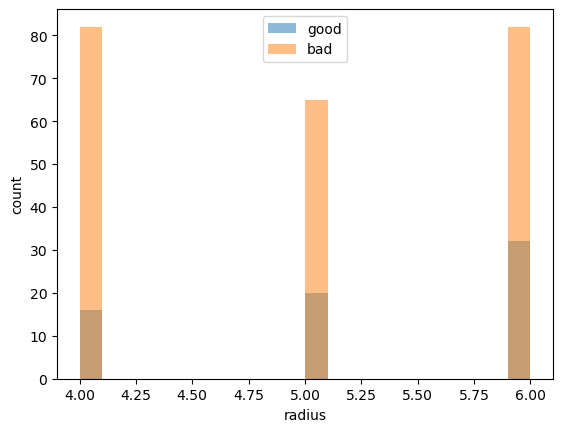

In [102]:
plt.hist(good_jobs.radius, bins=20, alpha=0.5, label="good")
plt.hist(bad_jobs.radius, bins=20, alpha=0.5, label="bad")

plt.legend()
plt.xlabel("radius")
plt.ylabel("count")
plt.show()

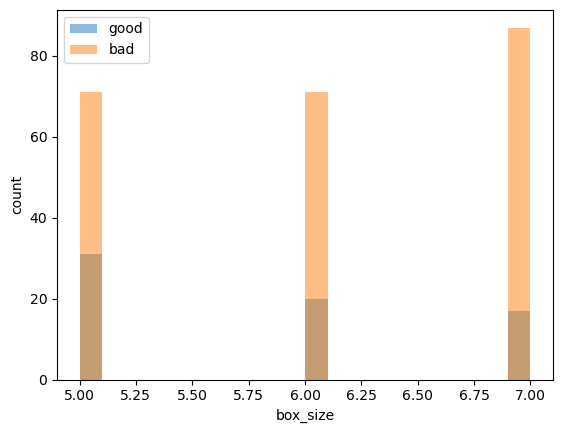

In [103]:
plt.hist(good_jobs.box_size, bins=20, alpha=0.5, label="good")
plt.hist(bad_jobs.box_size, bins=20, alpha=0.5, label="bad")

plt.legend()
plt.xlabel("box_size")
plt.ylabel("count")
plt.show()

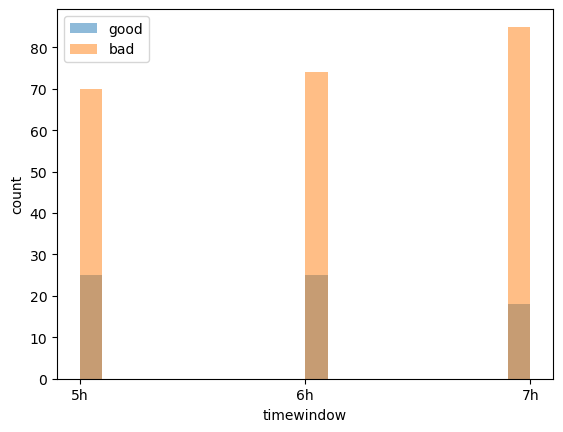

In [104]:
plt.hist(good_jobs.timewindow, bins=20, alpha=0.5, label="good")
plt.hist(bad_jobs.timewindow, bins=20, alpha=0.5, label="bad")

plt.legend()
plt.xlabel("timewindow")
plt.ylabel("count")
plt.show()

(array([ 1.,  5., 18., 11.,  8.,  8.,  3., 10.,  2.,  2.]),
 array([ 418680. ,  730230.8, 1041781.6, 1353332.4, 1664883.2, 1976434. ,
        2287984.8, 2599535.6, 2911086.4, 3222637.2, 3534188. ]),
 <BarContainer object of 10 artists>)

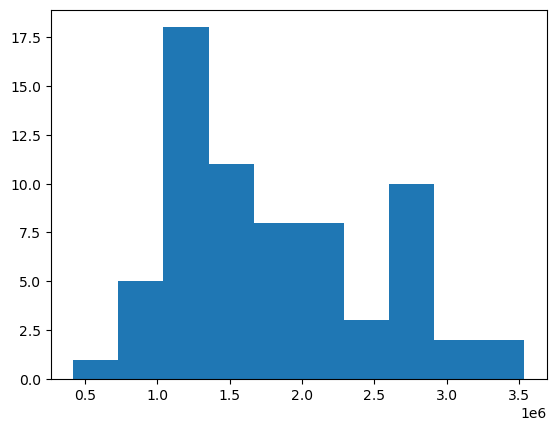

In [105]:
plt.hist(good_jobs['density_range::vo']-good_jobs['density_range::precip'])
# plt.hist()

In [106]:
import json
from pathlib import Path
import copy
import numpy as np
import pandas as pd
import xarray as xr

# ==================================================
# Choose trial
# ==================================================
trial_id_plot = 107   # <--- change this

# ==================================================
# Locate row and bundle
# ==================================================
row = jobs_df.loc[jobs_df["trial_id"] == trial_id_plot]
if len(row) == 0:
    raise ValueError(f"trial_id={trial_id_plot} not found in jobs_df")

row = row.iloc[0]

bundle_npz_path = Path(row["bundle_npz"])
bundle_json_path = Path(row["bundle_json"])

if not bundle_npz_path.exists():
    raise FileNotFoundError(bundle_npz_path)
if not bundle_json_path.exists():
    raise FileNotFoundError(bundle_json_path)

bundle_npz = np.load(bundle_npz_path, allow_pickle=True)
with open(bundle_json_path, "r", encoding="utf-8") as f:
    bundle_meta = json.load(f)

params_trial = copy.deepcopy(bundle_meta["params"])

print("trial_id:", trial_id_plot)
print("bundle:", bundle_npz_path.name)
print("status:", row.get("status", "NA"))
print("mean traj length:", row.get("mean_traj_length", np.nan))
print("mean member mean track dist (km):", row.get("mean_of_member_mean_track_dist_km", np.nan))

# ==================================================
# Rebuild Debby data
# ==================================================
path_files_debby = "/glade/derecho/scratch/jhayron/DataCaStLeBTs/FilesDebby/"

var_tb = xr.open_dataset(f"{path_files_debby}/BT_anomalies_TC_argon.nc4").Tb
var_vo = xr.open_dataset(f"{path_files_debby}/Vo_anomalies_TC_500-700.nc4").vo
var_pr = xr.open_dataset(f"{path_files_debby}/P_anomalies_TC_argon2.nc4").precipitation

datalist = []
for timetemp in var_pr.time:
    hourtemp = pd.to_datetime(timetemp.values).hour
    datatemp = var_pr.sel(time=timetemp, hour=hourtemp)
    datalist.append(datatemp)

var_pr = xr.concat(datalist, dim="time").fillna(0)

var_vo = var_vo.rename({"latitude": "lat", "longitude": "lon"})
var_tb = var_tb.assign_coords(time=var_tb.time.dt.round("1H"))
var_vo = var_vo.assign_coords(time=var_vo.time.dt.round("1H"))
var_pr = var_pr.assign_coords(time=var_pr.time.dt.round("1H"))

full_data_debby = xr.concat(
    [var_tb, var_vo, var_pr],
    dim=xr.IndexVariable("var", ["Tb", "vo", "precip"])
)
full_data_debby = full_data_debby.assign_coords(
    lon=(full_data_debby.lon % 360)
).sortby("lon")

# ==================================================
# Observed Debby track
# ==================================================
date_end_debby = "2006-08-26 00:00:00"
event_lat_debby = 28.0
event_lon_debby = -46.0

ds_tracks = xr.open_dataset("IBTrACS.NA.v04r01.nc")
where_debby = np.where(ds_tracks.sid == b"2006234N12338")[0][0]

time_storm = pd.to_datetime(ds_tracks.time.values[where_debby])
lat_storm = np.asarray(ds_tracks.lat.values[where_debby], dtype=float)
lon_storm = np.asarray(ds_tracks.lon.values[where_debby], dtype=float)

valid = (~pd.isna(time_storm)) & np.isfinite(lat_storm) & np.isfinite(lon_storm)
time_storm = pd.to_datetime(time_storm[valid])
lat_storm = lat_storm[valid]
lon_storm = lon_storm[valid]

lon_storm_plot = ((lon_storm + 180) % 360) - 180

date_end_dt = pd.Timestamp(date_end_debby)
hours_back_storm = (date_end_dt - time_storm) / pd.Timedelta(hours=1)

valid_back = hours_back_storm >= 0
time_storm = time_storm[valid_back]
lat_storm = lat_storm[valid_back]
lon_storm_plot = lon_storm_plot[valid_back]
hours_back_storm = np.asarray(hours_back_storm[valid_back], dtype=float)

# ==================================================
# Reconstruct ensemble from bundle
# ==================================================
centers_pad = bundle_npz["centers"]
parents_pad = bundle_npz["parents"]
lengths = bundle_npz["lengths"]
ok_arr = bundle_npz["ok"]
member_ids = bundle_npz["member_id"]

ensemble_results_trial = []
for i in range(len(lengths)):
    L = int(lengths[i])
    if int(ok_arr[i]) != 1 or L <= 0:
        continue

    ensemble_results_trial.append({
        "member_id": int(member_ids[i]),
        "centers": np.asarray(centers_pad[i, :L, :], dtype=float),
        "parents": np.asarray(parents_pad[i, :L], dtype=int),
    })

print("usable ensemble members:", len(ensemble_results_trial))

# ==================================================
# Deterministic run using this trial's hyperparameters
# ==================================================
params_det = copy.deepcopy(params_trial)
params_det["montecarlo"] = False
params_det["starting_lat"] = event_lat_debby
params_det["starting_lon"] = event_lon_debby

centers_det, parents_det, out_det = run_one_track(
    full_data_debby,
    params_det,
    date_end_debby,
)

trial_id: 107
bundle: debby_trial_00107.npz
status: ok
mean traj length: 308.8333333333333
mean member mean track dist (km): 757.1847807164605
usable ensemble members: 30


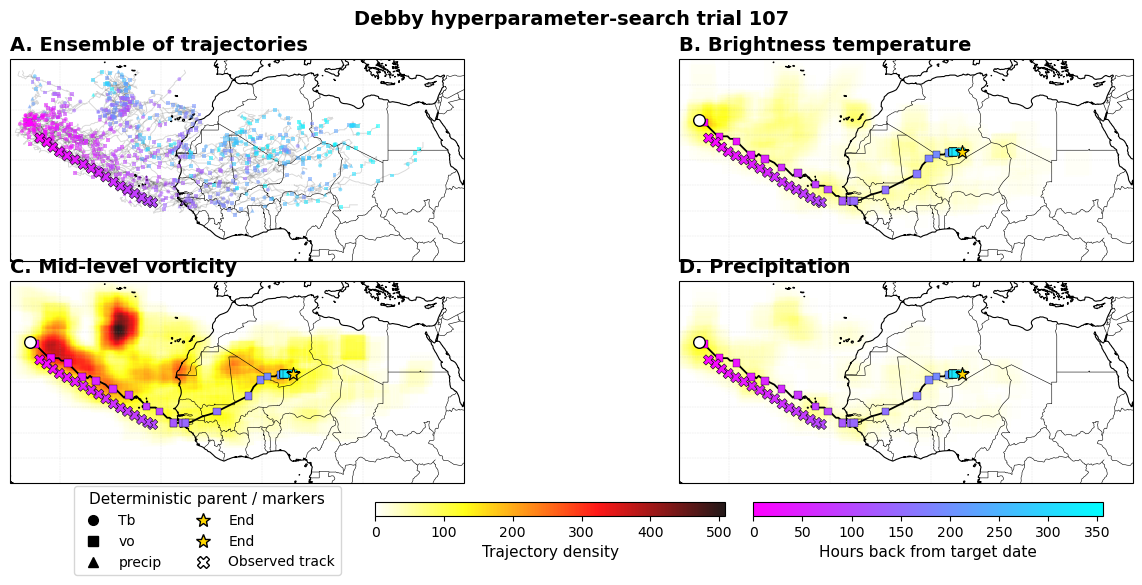

In [107]:
# ==================================================
# Plot
# ==================================================
extent_debby = (-50, 40, 0, 40)

panel_vars_debby = ["Tb", "vo", "precip"]
panel_titles_debby = {
    "Tb": "Brightness temperature",
    "vo": "Mid-level vorticity",
    "precip": "Precipitation",
}
contour_mode_debby = {
    "Tb": "both",
    "vo": "positive",
    "precip": "positive",
}

fig, axes = plot_trace_st_debby_4panel(
    full_data_run=full_data_debby,
    centers_det=centers_det,
    parents_det=parents_det,
    ensemble_results=ensemble_results_trial,
    date_end=date_end_debby,
    box_size_deg=float(params_trial["box_size"]),
    panel_vars=panel_vars_debby,
    panel_titles=panel_titles_debby,
    contour_every=48,
    contour_level_std=100,
    contour_mode=contour_mode_debby,
    timeres_hours=1.0,
    extent=extent_debby,
    density_cmap="hot_r",
    track_cmap="cool_r",
    density_alpha=0.9,
    contour_linewidth=1.0,
    track_linewidth=1.3,
    point_size=30,
    scatter_stride=12,
    ensemble_linewidth=0.7,
    ensemble_alpha=0.15,
    ensemble_markersize=8,
    normalize_density=False,
    density_percentile_cap=100.0,
    event_lon=event_lon_debby,
    event_lat=event_lat_debby,
    event_label="Target",
    storm_lon=lon_storm_plot,
    storm_lat=lat_storm,
    storm_hours_back=hours_back_storm,
    storm_marker="X",
    storm_marker_size=55,
    storm_stride=2,
)

fig.suptitle(
    f"Debby hyperparameter-search trial {trial_id_plot}",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

plt.show()

/glade/derecho/scratch/jhayron/tmp/ipykernel_4193/2602043107.py:486: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axE.boxplot(


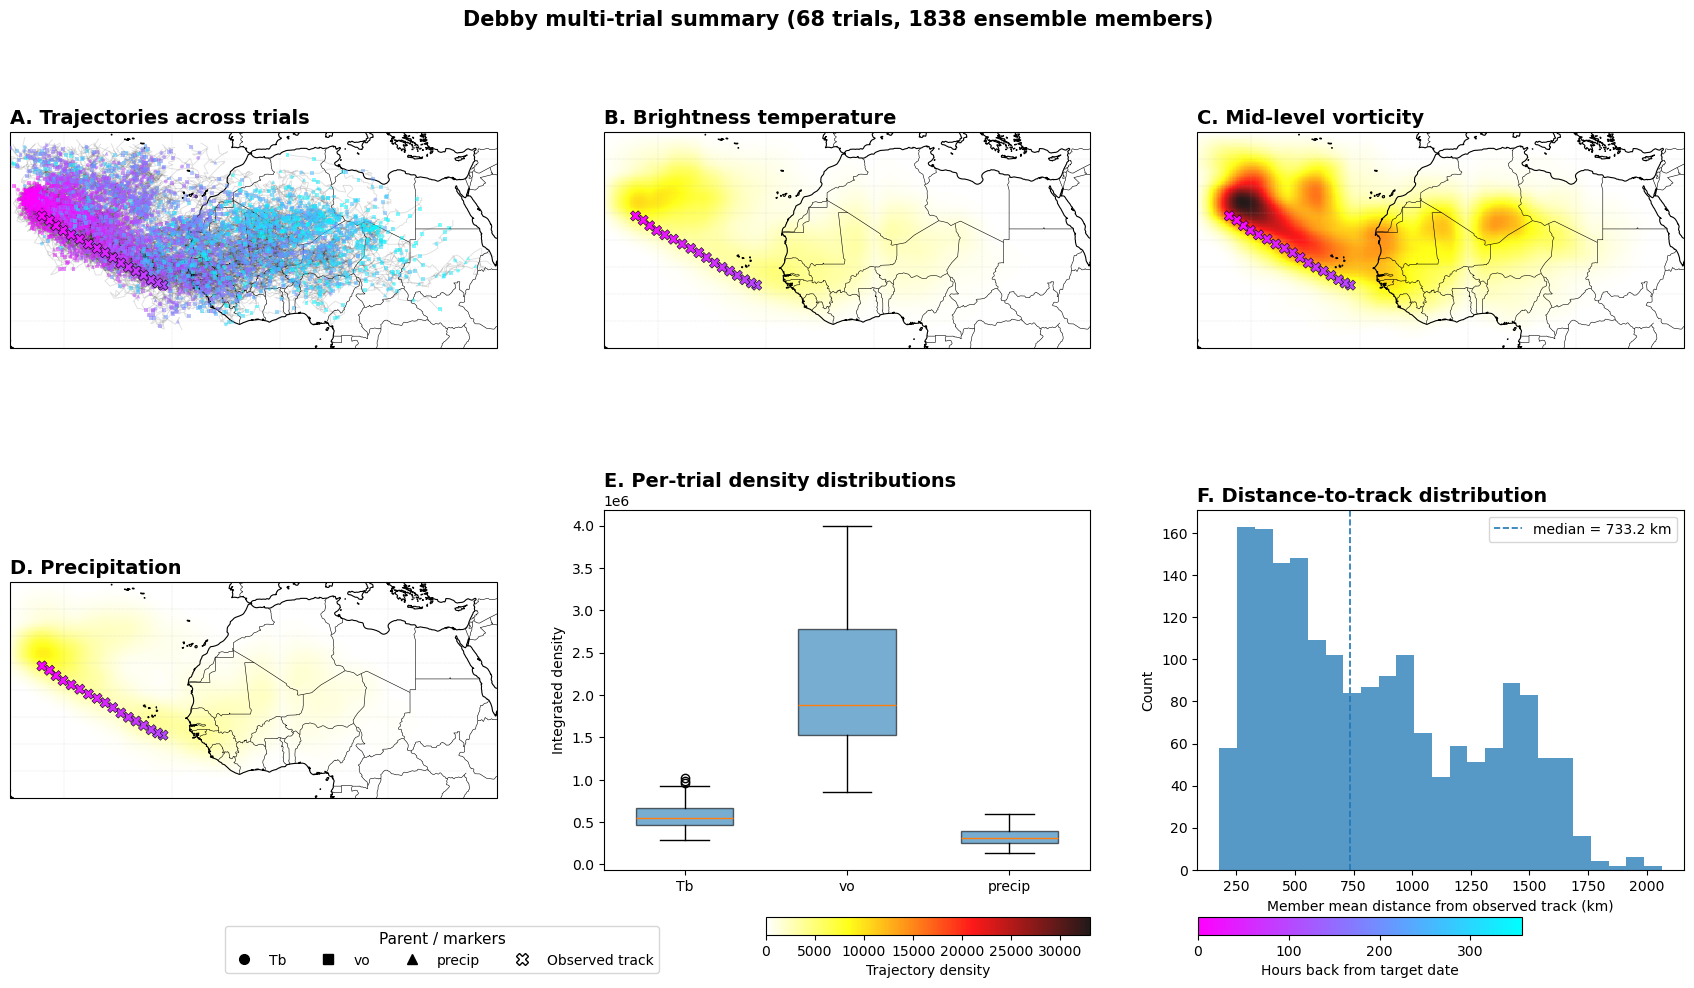

In [108]:

# =========================================================
# Example call
# =========================================================
trial_ids_plot = good_jobs.trial_id   # <--- change this

fig = plot_trace_st_debby_6panel_multi_trials(
    trial_ids=trial_ids_plot,
    jobs_df=jobs_df,
    members_df=members_df,
    full_data_run=full_data_debby,
    date_end=date_end_debby,
    run_one_track=run_one_track,
    panel_vars=("Tb", "vo", "precip"),
    panel_titles={
        "Tb": "Brightness temperature",
        "vo": "Mid-level vorticity",
        "precip": "Precipitation",
    },
    contour_every=48,
    contour_level_std=100,
    contour_mode={
        "Tb": "both",
        "vo": "positive",
        "precip": "positive",
    },
    timeres_hours=1.0,
    extent=extent_debby,
    density_cmap="hot_r",
    track_cmap="cool_r",
    density_alpha=0.9,
    contour_linewidth=1.0,
    track_linewidth=1.1,
    point_size=18,
    scatter_stride=12,
    ensemble_linewidth=0.7,
    ensemble_alpha=0.12,
    ensemble_markersize=8,
    density_percentile_cap=100.0,
    event_lon=event_lon_debby,
    event_lat=event_lat_debby,
    storm_lon=lon_storm_plot,
    storm_lat=lat_storm,
    storm_hours_back=hours_back_storm,
    storm_marker="X",
    storm_marker_size=55,
    storm_stride=2,
    distance_metric_col="track_dist_km_mean",
    density_boxplot_cols=("density_range::Tb", "density_range::vo", "density_range::precip"),
    random_members_per_trial=3
)

plt.show()

In [109]:
good_jobs

,case_name,trial_id,timeres,spaceres,box_size,radius,starting_lat,starting_lon,timewindow,child_of_interest,...,density_range_end_step_exclusive,density_range::Tb,density_range::vo,density_range::precip,elapsed_sec,status,ok,error,bundle_npz,bundle_json
0,debby,111,1h,0.25,6.0,6,28.0,-46.0,5h,3,...,360,565104.0,3146352.0,437784.0,2614.971661,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
1,debby,76,1h,0.25,6.0,6,28.0,-46.0,5h,3,...,360,399816.0,2364984.0,457344.0,2272.634097,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
2,debby,186,1h,0.25,7.0,6,28.0,-46.0,5h,3,...,360,544488.0,3625244.0,509152.0,3149.357248,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
3,debby,259,1h,0.25,6.0,5,28.0,-46.0,5h,3,...,360,459072.0,2650416.0,376608.0,2070.294749,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
4,debby,118,1h,0.25,6.0,6,28.0,-46.0,6h,3,...,360,642792.0,2694456.0,428856.0,2976.727537,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,debby,10,1h,0.25,5.0,4,28.0,-46.0,6h,3,...,360,434960.0,1311240.0,235840.0,1620.194246,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
125,debby,16,1h,0.25,7.0,5,28.0,-46.0,7h,3,...,360,553168.0,2455348.0,360836.0,4518.359571,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
148,debby,69,1h,0.25,5.0,5,28.0,-46.0,5h,3,...,360,431960.0,1445323.0,253180.0,1916.163324,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
161,debby,113,1h,0.25,5.0,5,28.0,-46.0,6h,3,...,360,409460.0,1184380.0,234960.0,1674.548083,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...


In [110]:
len(good_jobs.trial_id.values)

68

In [112]:
jobs_df.copy()

,case_name,trial_id,timeres,spaceres,box_size,radius,starting_lat,starting_lon,timewindow,child_of_interest,...,density_range_end_step_exclusive,density_range::Tb,density_range::vo,density_range::precip,elapsed_sec,status,ok,error,bundle_npz,bundle_json
0,debby,111,1h,0.25,6.0,6,28.0,-46.0,5h,3,...,360,565104.0,3146352.0,437784.0,2614.971661,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
1,debby,76,1h,0.25,6.0,6,28.0,-46.0,5h,3,...,360,399816.0,2364984.0,457344.0,2272.634097,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
2,debby,186,1h,0.25,7.0,6,28.0,-46.0,5h,3,...,360,544488.0,3625244.0,509152.0,3149.357248,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
3,debby,259,1h,0.25,6.0,5,28.0,-46.0,5h,3,...,360,459072.0,2650416.0,376608.0,2070.294749,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
4,debby,118,1h,0.25,6.0,6,28.0,-46.0,6h,3,...,360,642792.0,2694456.0,428856.0,2976.727537,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,debby,52,1h,0.25,6.0,5,28.0,-46.0,7h,3,...,360,240840.0,1101744.0,201720.0,3786.527217,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
296,debby,8,1h,0.25,5.0,4,28.0,-46.0,5h,3,...,360,261440.0,837040.0,191120.0,2101.092844,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
297,debby,278,1h,0.25,6.0,5,28.0,-46.0,7h,3,...,360,332856.0,1053576.0,239808.0,2953.061492,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
298,debby,251,1h,0.25,5.0,5,28.0,-46.0,7h,3,...,360,201906.0,291140.0,101160.0,2222.985516,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...


In [113]:
debby_trial_ids = good_jobs.trial_id
jobs_df_debby = jobs_df.copy()
members_df_debby = members_df.copy()
storm_lon = lon_storm_plot.copy()
storm_lat = lat_storm.copy()
storm_hours_back = hours_back_storm.copy()

# Results Pinatubo

In [114]:
OUTDIR = Path("/glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsPinatubo/hp_search_v10")
BUNDLES_DIR = OUTDIR / "bundles"

jobs_csv_final = OUTDIR / "results_jobs_final.csv"
alphas_csv_final = OUTDIR / "results_alphas_final.csv"
members_csv_final = OUTDIR / "results_members_final.csv"

jobs_csv_snapshot = OUTDIR / "results_jobs_snapshot.csv"
alphas_csv_snapshot = OUTDIR / "results_alphas_snapshot.csv"
members_csv_snapshot = OUTDIR / "results_members_snapshot.csv"

jobs_jsonl = OUTDIR / "results_jobs.jsonl"
alphas_jsonl = OUTDIR / "results_alphas.jsonl"
members_jsonl = OUTDIR / "results_members.jsonl"

meta_json = OUTDIR / "run_metadata.json"
summary_json = OUTDIR / "run_summary.json"

print("OUTDIR:", OUTDIR)
print("Exists:", OUTDIR.exists())
print("Bundles dir exists:", BUNDLES_DIR.exists())


if jobs_csv_final.exists():
    jobs_df = pd.read_csv(jobs_csv_final)
elif jobs_csv_snapshot.exists():
    jobs_df = pd.read_csv(jobs_csv_snapshot)
else:
    jobs_df = pd.DataFrame(load_jsonl(jobs_jsonl))

if members_csv_final.exists():
    members_df = pd.read_csv(members_csv_final)
elif members_csv_snapshot.exists():
    members_df = pd.read_csv(members_csv_snapshot)
else:
    members_df = pd.DataFrame(load_jsonl(members_jsonl))

meta = load_json(meta_json) if meta_json.exists() else {}
summary = load_json(summary_json) if summary_json.exists() else {}

bundle_npz_files = sorted(BUNDLES_DIR.glob("*.npz")) if BUNDLES_DIR.exists() else []
bundle_json_files = sorted(BUNDLES_DIR.glob("*.json")) if BUNDLES_DIR.exists() else []

summarize_table("jobs_df", jobs_df)
summarize_table("members_df", members_df)

print("n bundle npz files:", len(bundle_npz_files))
print("n bundle json files:", len(bundle_json_files))

if meta:
    print("\nrun_metadata:")
    for k, v in meta.items():
        print(f"  {k}: {v}")

if summary:
    print("\nrun_summary:")
    for k, v in summary.items():
        print(f"  {k}: {v}")

OUTDIR: /glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsPinatubo/hp_search_v10
Exists: True
Bundles dir exists: True
jobs_df: shape=(1000, 95)
  columns=['case_name', 'trial_id', 'timeres', 'spaceres', 'box_size', 'radius', 'starting_lat', 'starting_lon', 'timewindow', 'child_of_interest', 'n_steps_time', 'averaging_winners'] ...
members_df: shape=(30000, 48)
  columns=['member_id', 'ok', 'error', 'final_dist_to_volcano_km', 'n_steps', 'path_length', 'net_displacement', 'mean_step', 'stagnant_frac', 'end_parent', 'frac_parent1', 'frac_parent2'] ...
n bundle npz files: 1000
n bundle json files: 1000

run_metadata:
  case_name: pinatubo
  seed: 11
  n_trials: 1000
  n_workers: 120
  ensemble_size: 30
  flush_every: 10
  n_total_trials: 1000
  n_completed_trials_found_at_start: 0
  n_pending_trials_at_start: 1000
  updated_at: 2026-04-06T00:18:15.641962+00:00

run_summary:
  finished_at: 2026-04-06T00:26:01.791496+00:00
  elapsed_sec: 466.1468639788218
  n_trials_total: 1000
  n_trial

In [115]:
jobs_df.keys()

Index(['case_name', 'trial_id', 'timeres', 'spaceres', 'box_size', 'radius',
       'starting_lat', 'starting_lon', 'timewindow', 'child_of_interest',
       'n_steps_time', 'averaging_winners', 'snap_to_grid', 'montecarlo',
       'beta_softmax', 'eps_dbscan', 'min_samples_dbscan', 'score_mode',
       'gamma', 'alpha', 'prefer_sign', 'verbose', 'prob_rule',
       'winner_summary', 'cd_method', 'cd_kwargs.lambda_a',
       'cd_kwargs.l1_ratio', 'cd_kwargs.dependence_threshold',
       'cd_kwargs.max_iter', 'cd_kwargs.fit_intercept',
       'cd_kwargs.refit_ridge', 'cd_kwargs.ridge_alpha', 'n_members_requested',
       'n_members_success', 'n_members_failed', 'success_rate',
       'mean_traj_length', 'median_traj_length', 'std_traj_length',
       'min_traj_length', 'max_traj_length', 'mean_mean_step',
       'median_mean_step', 'std_mean_step', 'mean_net_displacement',
       'median_net_displacement', 'std_net_displacement',
       'n_members_with_valid_track', 'mean_final_dist_to_

(array([  5.,   8.,  28.,  67., 493., 275.,  84.,  30.,   7.,   3.]),
 array([32.71249567, 33.81571402, 34.91893238, 36.02215073, 37.12536908,
        38.22858744, 39.33180579, 40.43502414, 41.5382425 , 42.64146085,
        43.7446792 ]),
 <BarContainer object of 10 artists>)

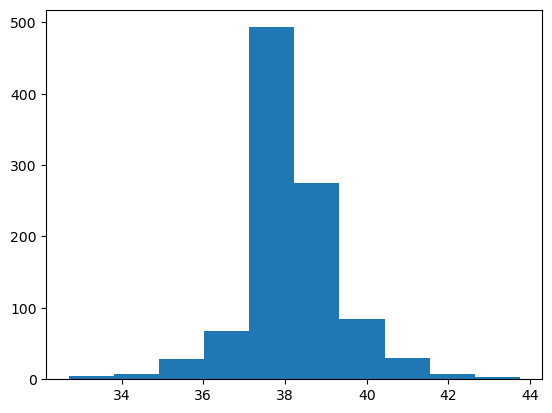

In [116]:
plt.hist(jobs_df['mean_mean_step'])

In [117]:
jobs_df.keys()

Index(['case_name', 'trial_id', 'timeres', 'spaceres', 'box_size', 'radius',
       'starting_lat', 'starting_lon', 'timewindow', 'child_of_interest',
       'n_steps_time', 'averaging_winners', 'snap_to_grid', 'montecarlo',
       'beta_softmax', 'eps_dbscan', 'min_samples_dbscan', 'score_mode',
       'gamma', 'alpha', 'prefer_sign', 'verbose', 'prob_rule',
       'winner_summary', 'cd_method', 'cd_kwargs.lambda_a',
       'cd_kwargs.l1_ratio', 'cd_kwargs.dependence_threshold',
       'cd_kwargs.max_iter', 'cd_kwargs.fit_intercept',
       'cd_kwargs.refit_ridge', 'cd_kwargs.ridge_alpha', 'n_members_requested',
       'n_members_success', 'n_members_failed', 'success_rate',
       'mean_traj_length', 'median_traj_length', 'std_traj_length',
       'min_traj_length', 'max_traj_length', 'mean_mean_step',
       'median_mean_step', 'std_mean_step', 'mean_net_displacement',
       'median_net_displacement', 'std_net_displacement',
       'n_members_with_valid_track', 'mean_final_dist_to_

In [118]:
# good_jobs = jobs_df[(jobs_df['mean_mean_step']>15)&(jobs_df['density_range_dominant_var']=='TMSO201')&\
#     (jobs_df['density_full::BURDENSO401']>jobs_df['density_full::AEROD_v'])]
# bad_jobs = jobs_df[(jobs_df['mean_mean_step']<15)|(jobs_df['density_range_dominant_var']!='TMSO201')|\
#     (jobs_df['density_full::BURDENSO401']<jobs_df['density_full::AEROD_v'])]

In [119]:
# good_jobs = jobs_df[(jobs_df['mean_mean_step']>12)&(jobs_df['density_range_dominant_var']=='TMSO201')&\
#     (jobs_df['density_range::BURDENSO401']>8000)&(jobs_df['mean_final_dist_to_volcano_km']<7000)]
# bad_jobs = jobs_df[(jobs_df['mean_mean_step']<12)|(jobs_df['density_range_dominant_var']!='TMSO201')|\
#     (jobs_df['density_range::BURDENSO401']<8000)|(jobs_df['mean_final_dist_to_volcano_km']>7000)]

In [120]:
# good_jobs = jobs_df[(jobs_df['mean_mean_step']>15)&(jobs_df['density_range_dominant_var']=='TMSO201')]
# bad_jobs = jobs_df[(jobs_df['mean_mean_step']<15)|(jobs_df['density_range_dominant_var']!='TMSO201')]

In [121]:
# good_jobs = jobs_df[(jobs_df['mean_mean_step']>10)]
# bad_jobs = jobs_df[(jobs_df['mean_mean_step']<10)]

In [122]:
good_jobs = jobs_df[(jobs_df['n_members_failed']<10)&(jobs_df['mean_traj_length']>15)]
bad_jobs = jobs_df[(jobs_df['n_members_failed']>10)|(jobs_df['mean_traj_length']<15)]

In [123]:
len(good_jobs)/len(jobs_df)

0.999

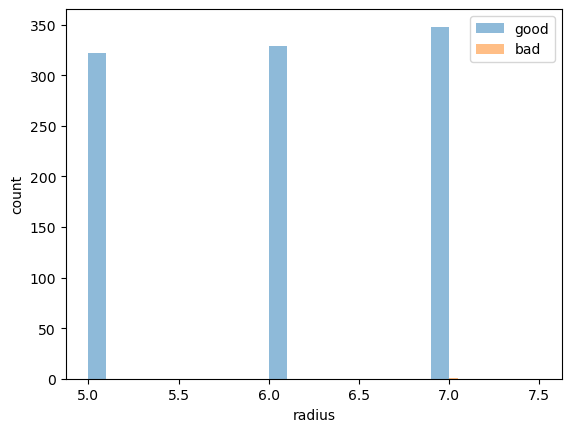

In [124]:
plt.hist(good_jobs.radius, bins=20, alpha=0.5, label="good")
plt.hist(bad_jobs.radius, bins=20, alpha=0.5, label="bad")

plt.legend()
plt.xlabel("radius")
plt.ylabel("count")
plt.show()

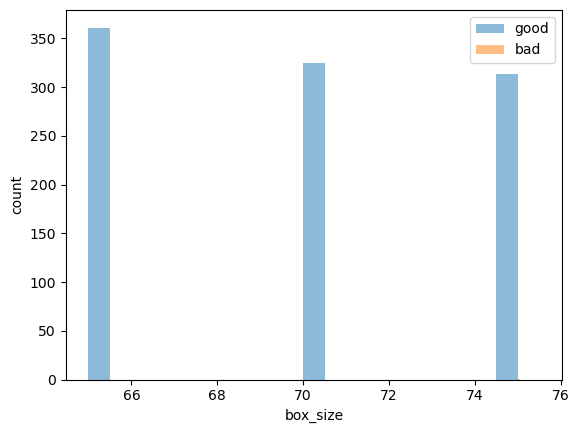

In [125]:
plt.hist(good_jobs.box_size, bins=20, alpha=0.5, label="good")
plt.hist(bad_jobs.box_size, bins=20, alpha=0.5, label="bad")

plt.legend()
plt.xlabel("box_size")
plt.ylabel("count")
plt.show()

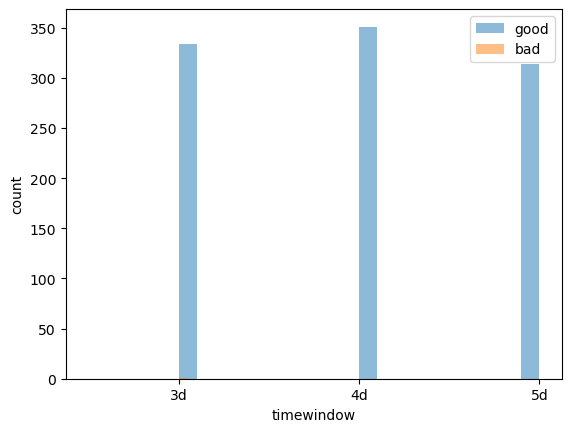

In [126]:
plt.hist(good_jobs.timewindow, bins=20, alpha=0.5, label="good")
plt.hist(bad_jobs.timewindow, bins=20, alpha=0.5, label="bad")

plt.legend()
plt.xlabel("timewindow")
plt.ylabel("count")
plt.show()

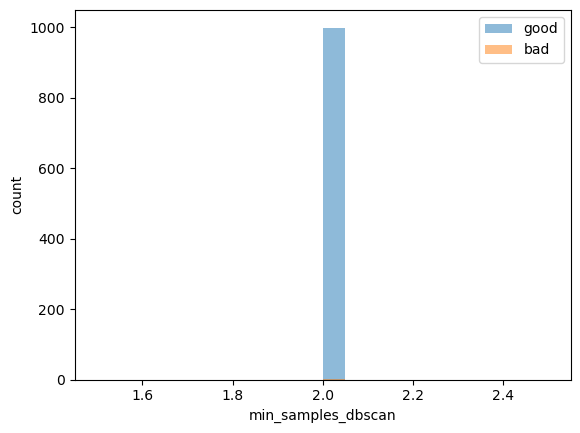

In [127]:
plt.hist(good_jobs.min_samples_dbscan, bins=20, alpha=0.5, label="good")
plt.hist(bad_jobs.min_samples_dbscan, bins=20, alpha=0.5, label="bad")

plt.legend()
plt.xlabel("min_samples_dbscan")
plt.ylabel("count")
plt.show()

(array([971.,   0.,   0.,   3.,   0.,   0.,   0.,   0.,   0.,  25.]),
 array([1. , 1.3, 1.6, 1.9, 2.2, 2.5, 2.8, 3.1, 3.4, 3.7, 4. ]),
 <BarContainer object of 10 artists>)

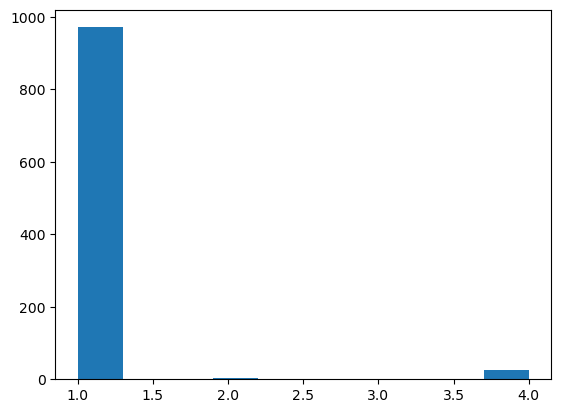

In [128]:
plt.hist(good_jobs['most_repeated_parent_final'])

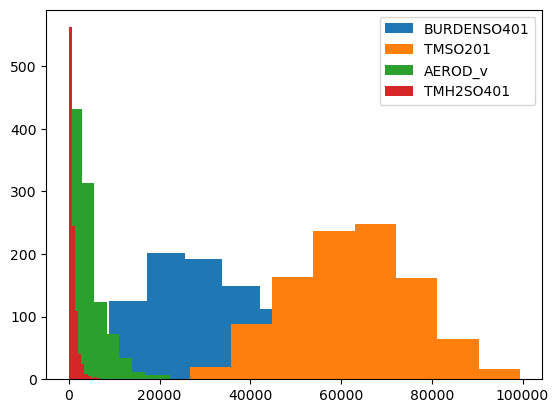

In [129]:
plt.hist(jobs_df['density_range::BURDENSO401'],label='BURDENSO401')
plt.hist(jobs_df['density_range::TMSO201'],label='TMSO201')
plt.hist(jobs_df['density_range::AEROD_v'],label='AEROD_v')
plt.hist(jobs_df['density_range::TMH2SO401'],label='TMH2SO401')
plt.legend()
# plt.hist()

In [130]:
def regrid_global_nearest(
    da,
    dlat=2.5,
    dlon=2.5,
    lat_name="lat",
    lon_name="lon",
):
    """
    Regrid a global DataArray to a regular lat-lon grid using nearest-neighbor interpolation.
    """
    da = da.sortby(lat_name).sortby(lon_name)

    new_lat = np.arange(-90 + dlat / 2, 90, dlat)
    new_lon = np.arange(0 + dlon / 2, 360, dlon)

    new_lat = new_lat[(new_lat >= -90) & (new_lat <= 90)]
    new_lon = new_lon[(new_lon >= 0) & (new_lon < 360)]

    da_out = da.interp(
        {
            lat_name: xr.DataArray(new_lat, dims=lat_name),
            lon_name: xr.DataArray(new_lon, dims=lon_name),
        },
        method="nearest",
    )
    return da_out

# --------------------------------------------------
# Pinatubo data
# --------------------------------------------------
PATH_FILES_PINATUBO = "/glade/derecho/scratch/jhayron/DataCaStLeBTs/Sandia/"
# --------------------------------------------------
# Pinatubo event definition
# --------------------------------------------------
event_lat_pinatubo = 15
event_lon_pinatubo = -160
date_end_pinatubo = "1991-07-02 00:00:00"

volcano_lat_pinatubo = 15.13
volcano_lon_pinatubo = 120.35

extent_pinatubo=(-180, 180, -25, 55)
res_pinatubo = 4

names_vars_pinatubo = ["TMSO201", "BURDENSO401", "TMH2SO401", "AEROD_v"]

vars_list_pinatubo = []
for var in names_vars_pinatubo:
    vars_list_pinatubo.append(
        xr.open_dataset(f"{PATH_FILES_PINATUBO}{var}_199101_199112.nc")[var]
    )

full_data_pinatubo = xr.concat(vars_list_pinatubo, dim="var").transpose("var", "lat", "lon", "time")
full_data_pinatubo = full_data_pinatubo.assign_coords(var=names_vars_pinatubo)
full_data_pinatubo["time"] = full_data_pinatubo.indexes["time"].to_datetimeindex()

full_data_pinatubo = regrid_global_nearest(full_data_pinatubo, dlat=res_pinatubo, dlon=res_pinatubo)

full_data_pinatubo = (
    full_data_pinatubo - full_data_pinatubo.mean("time")
) / full_data_pinatubo.std("time")

full_data_pinatubo = full_data_pinatubo.assign_coords(
    lon=(full_data_pinatubo.lon % 360)
).sortby("lon")

full_data_pinatubo

/glade/derecho/scratch/jhayron/tmp/ipykernel_4193/2404225399.py:55: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  full_data_pinatubo["time"] = full_data_pinatubo.indexes["time"].to_datetimeindex()


<xarray.DataArray 'TMSO201' (var: 4, lat: 45, lon: 90, time: 215)> Size: 14MB
array([[[[-0.933959  , -0.933959  , -0.933959  , ..., -0.59906757,
          -0.61470366, -0.63109446],
         [-0.93398374, -0.93398374, -0.93398374, ..., -0.59909976,
          -0.61473346, -0.63114667],
         [-0.9340373 , -0.9340373 , -0.9340373 , ..., -0.59916955,
          -0.6147981 , -0.63126034],
         ...,
         [-0.9340651 , -0.9340651 , -0.9340651 , ..., -0.59783554,
          -0.6085517 , -0.6323178 ],
         [-0.9340003 , -0.9340003 , -0.9340003 , ..., -0.59780073,
          -0.6085092 , -0.632189  ],
         [-0.9339665 , -0.9339665 , -0.9339665 , ..., -0.5977825 ,
          -0.60848695, -0.6321221 ]],

        [[-0.9294266 , -0.9294266 , -0.9294266 , ..., -0.59241617,
          -0.60925806, -0.60572994],
         [-0.9294266 , -0.9294266 , -0.9294266 , ..., -0.59241617,
          -0.60925806, -0.60572994],
         [-0.9294266 , -0.9294266 , -0.9294266 , ..., -0.59241617,
          -0.60925806, -0.60572994],
...
         [-1.0783062 , -0.8558682 , -1.6571751 , ...,         nan,
                  nan,         nan],
         [-1.090956  , -0.847335  , -1.6661686 , ...,         nan,
                  nan,         nan],
         [-1.097119  , -0.842623  , -1.6702384 , ...,         nan,
                  nan,         nan]],

        [[-0.961256  , -0.92400604, -1.2024854 , ...,         nan,
                  nan,         nan],
         [-0.961256  , -0.92400604, -1.2024854 , ...,         nan,
                  nan,         nan],
         [-0.961256  , -0.92400604, -1.2024854 , ...,         nan,
                  nan,         nan],
         ...,
         [-1.2668186 , -1.4070921 , -1.2823398 , ...,         nan,
                  nan,         nan],
         [-1.2668186 , -1.4070921 , -1.2823398 , ...,         nan,
                  nan,         nan],
         [-1.2668186 , -1.4070921 , -1.2823398 , ...,         nan,
                  nan,         nan]]]], dtype=float32)
Coordinates:
  * var      (var) <U11 176B 'TMSO201' 'BURDENSO401' 'TMH2SO401' 'AEROD_v'
  * time     (time) datetime64[ns] 2kB 1991-06-01 1991-06-02 ... 1992-01-01
  * lat      (lat) float64 360B -88.0 -84.0 -80.0 -76.0 ... 76.0 80.0 84.0 88.0
  * lon      (lon) float64 720B 2.0 6.0 10.0 14.0 ... 346.0 350.0 354.0 358.0

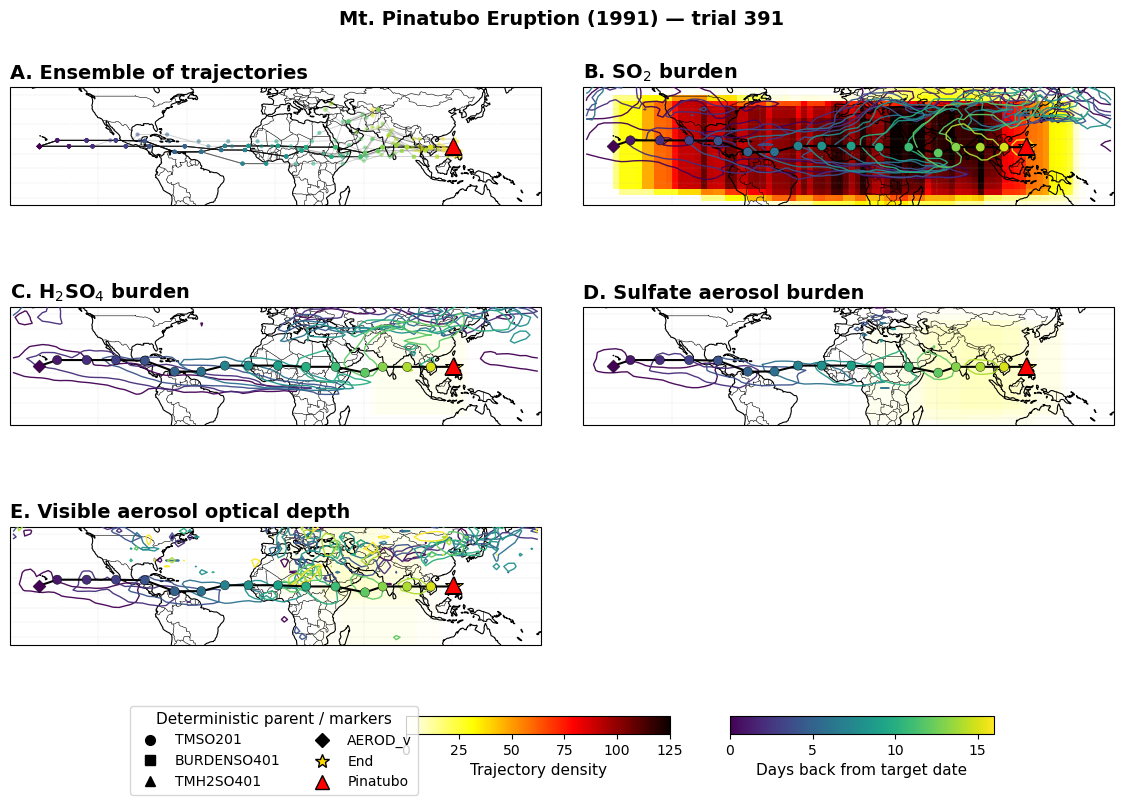

In [131]:
trial_id_plot = good_jobs.trial_id.iloc[0]

fig, axes = plot_trace_st_pinatubo_6panel_trial(
    trial_id=trial_id_plot,
    jobs_df=jobs_df,
    full_data_run=full_data_pinatubo,
    date_end=date_end_pinatubo,
    run_one_track=run_one_track,
    panel_vars=("TMSO201", "TMH2SO401", "BURDENSO401", "AEROD_v"),
    contour_every=2,
    contour_level_std=2.0,
    timeres_days=1.0,
    extent=(-180, 180, -25, 55),
    density_cmap="hot_r",
    track_cmap="viridis",
    density_alpha=1.0,
    contour_linewidth=1.0,
    track_linewidth=1.5,
    point_size=44,
    scatter_stride=1,
    ensemble_linewidth=0.7,
    ensemble_alpha=0.18,
    ensemble_markersize=9,
    normalize_density=False,
    density_percentile_cap=99.0,
    event_lon=lon0360_to_m180_180(volcano_lon_pinatubo),
    event_lat=volcano_lat_pinatubo,
    event_label="Pinatubo",
)
plt.show()

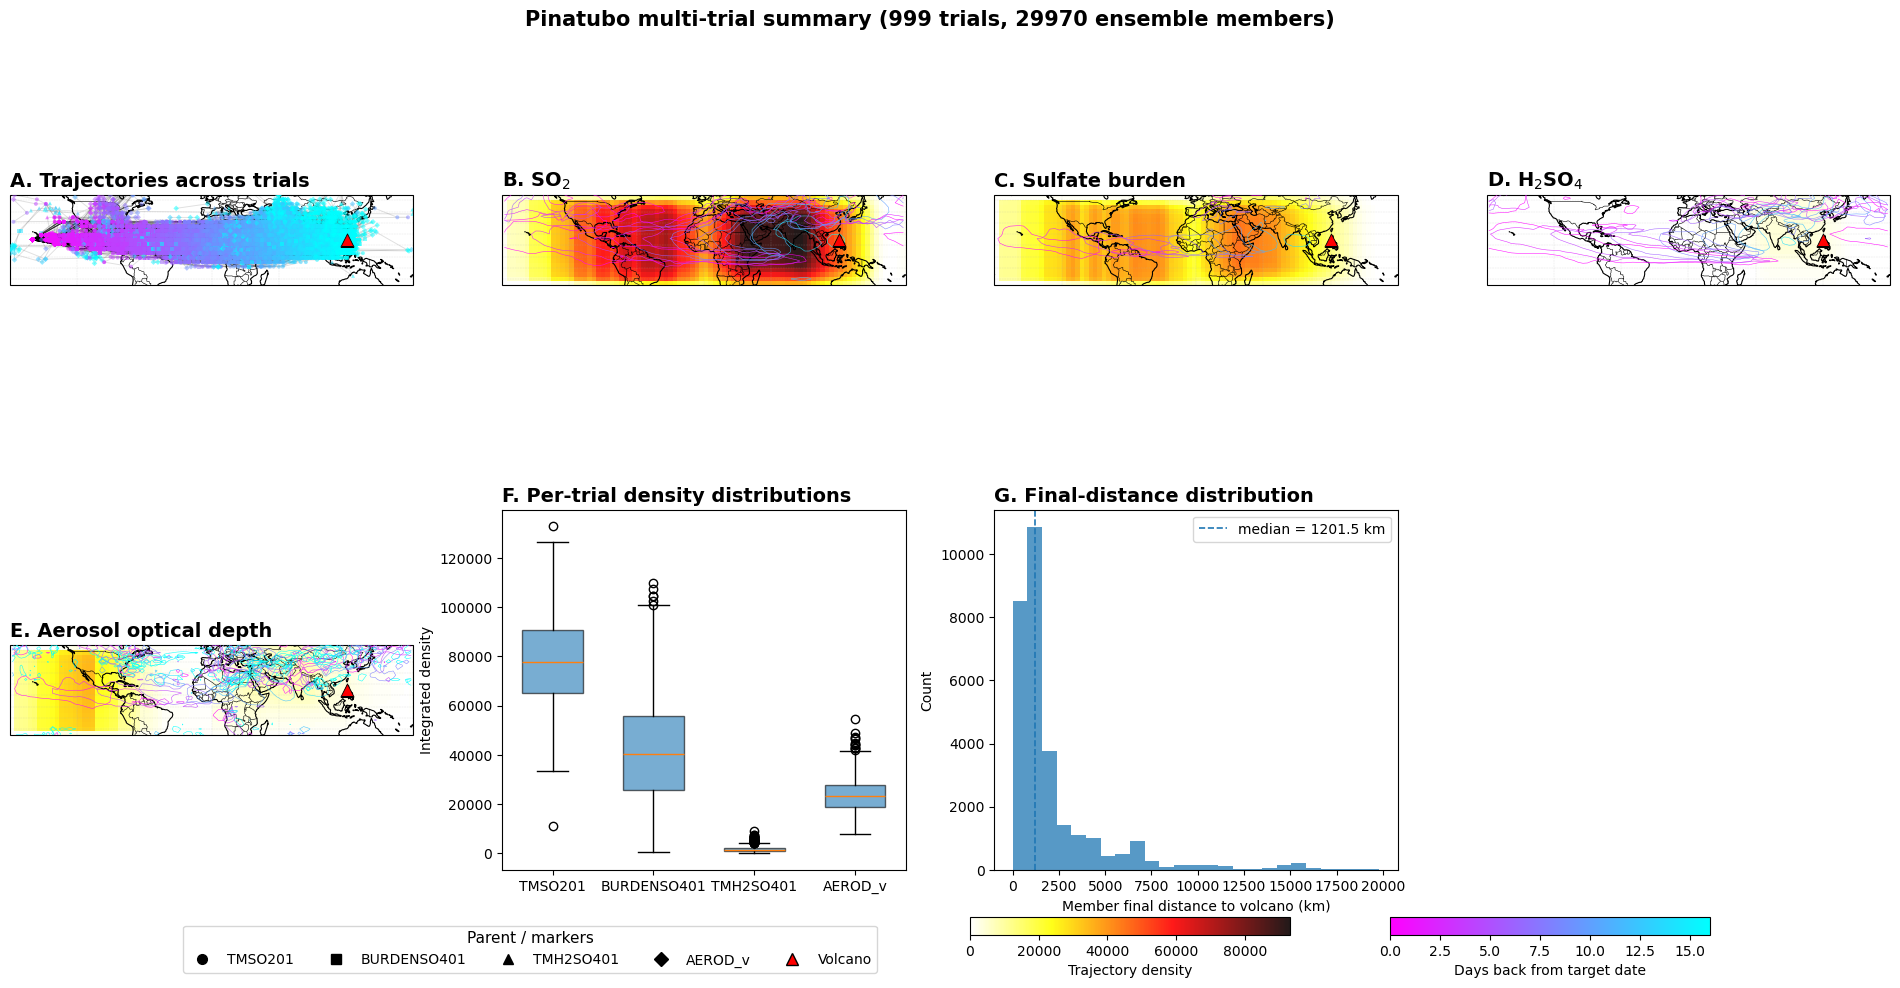

In [132]:
trial_ids_plot = good_jobs.trial_id   # or e.g. [12, 48, 77]

fig = plot_trace_st_pinatubo_7panel_multi_trials(
    trial_ids=trial_ids_plot,
    jobs_df=jobs_df,
    members_df=members_df,
    full_data_run=full_data_pinatubo,
    date_end=date_end_pinatubo,
    panel_vars=("TMSO201", "BURDENSO401", "TMH2SO401", "AEROD_v"),
    panel_titles={
        "TMSO201": "SO$_2$",
        "BURDENSO401": "Sulfate burden",
        "TMH2SO401": "H$_2$SO$_4$",
        "AEROD_v": "Aerosol optical depth",
    },
    contour_every=2,
    contour_level_std=1.0,
    contour_mode={
        "TMSO201": "positive",
        "BURDENSO401": "positive",
        "TMH2SO401": "positive",
        "AEROD_v": "positive",
    },
    timeres_days=1.0,
    extent=extent_pinatubo,
    density_cmap="hot_r",
    track_cmap="cool_r",
    density_alpha=0.9,
    contour_linewidth=0.4,
    ensemble_linewidth=0.7,
    ensemble_alpha=0.12,
    ensemble_markersize=8,
    scatter_stride=1,
    density_percentile_cap=100.0,
    volcano_lon=volcano_lon_pinatubo,
    volcano_lat=volcano_lat_pinatubo,
    volcano_marker="^",
    volcano_marker_size=90,
    distance_metric_col="final_dist_to_volcano_km",
    density_boxplot_cols=(
        "density_full::TMSO201",
        "density_full::BURDENSO401",
        "density_full::TMH2SO401",
        "density_full::AEROD_v",
    ),
    random_members_per_trial=3,
    random_seed=11,
)

plt.show()

In [51]:
# import numpy as np
# import pandas as pd

# # -----------------------------------------
# # Select hyperparameters only
# # -----------------------------------------
# hyper_cols = [
#     "box_size", "radius", "timewindow",
#     "eps_dbscan", "alpha",
#     "beta_softmax", "gamma",
#     "cd_kwargs.lambda_a",
#     "cd_kwargs.l1_ratio",
# ]

# # convert timewindow → numeric days
# def _tw_to_days(x):
#     try:
#         return float(str(x).replace("d", ""))
#     except:
#         return np.nan

# good = good_jobs.copy()
# bad = bad_jobs.copy()

# good["timewindow_days"] = good["timewindow"].apply(_tw_to_days)
# bad["timewindow_days"] = bad["timewindow"].apply(_tw_to_days)

# hyper_cols = [c if c != "timewindow" else "timewindow_days" for c in hyper_cols]

# # log-scale columns
# log_cols = [
#     "cd_kwargs.lambda_a",
#     "cd_kwargs.l1_ratio",
# ]

# def maybe_log(x, col):
#     if col in log_cols:
#         return np.log10(x.replace(0, np.nan))
#     return x

# rows = []

# for col in hyper_cols:
#     g = pd.to_numeric(good[col], errors="coerce").dropna()
#     b = pd.to_numeric(bad[col], errors="coerce").dropna()

#     if len(g) == 0 or len(b) == 0:
#         continue

#     g_t = maybe_log(g, col)
#     b_t = maybe_log(b, col)

#     def stats(x):
#         return {
#             "min": np.nanmin(x),
#             "q5": np.nanpercentile(x, 5),
#             "median": np.nanmedian(x),
#             "q95": np.nanpercentile(x, 95),
#             "max": np.nanmax(x),
#         }

#     sg = stats(g_t)
#     sb = stats(b_t)

#     overlap = not (sg["max"] < sb["min"] or sb["max"] < sg["min"])

#     rows.append({
#         "param": col,
#         "scale": "log10" if col in log_cols else "linear",

#         "good_min": sg["min"],
#         "good_q5": sg["q5"],
#         "good_median": sg["median"],
#         "good_q95": sg["q95"],
#         "good_max": sg["max"],

#         "bad_min": sb["min"],
#         "bad_q5": sb["q5"],
#         "bad_median": sb["median"],
#         "bad_q95": sb["q95"],
#         "bad_max": sb["max"],

#         "overlap": overlap,
#     })

# df_ranges = pd.DataFrame(rows).sort_values("overlap")

# display(df_ranges)

In [52]:
# import matplotlib.pyplot as plt

# plot_cols = hyper_cols

# ncols = 3
# nrows = int(np.ceil(len(plot_cols) / ncols))

# fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.2 * nrows))
# axes = axes.ravel()

# for ax, col in zip(axes, plot_cols):
#     g = pd.to_numeric(good[col], errors="coerce").dropna()
#     b = pd.to_numeric(bad[col], errors="coerce").dropna()

#     if len(g) == 0 or len(b) == 0:
#         ax.set_visible(False)
#         continue

#     if col in log_cols:
#         g = np.log10(g[g > 0])
#         b = np.log10(b[b > 0])
#         ax.set_xlabel(f"log10({col})")
#     else:
#         ax.set_xlabel(col)

#     bins = min(20, max(6, int(np.sqrt(len(g) + len(b)))))

#     ax.hist(b, bins=bins, alpha=0.5, density=True, label="bad")
#     ax.hist(g, bins=bins, alpha=0.7, density=True, label="good")

#     ax.axvline(np.median(g), linestyle="--")
#     ax.set_title(col)
#     ax.legend()

# for ax in axes[len(plot_cols):]:
#     ax.set_visible(False)

# plt.tight_layout()
# plt.show()

In [53]:
# import matplotlib.pyplot as plt

# pairs = [
#     ("box_size", "radius"),
#     ("box_size", "timewindow_days"),
#     ("radius", "timewindow_days"),
#     ("eps_dbscan", "alpha"),
#     ("cd_kwargs.lambda_a", "cd_kwargs.l1_ratio"),
#     ("box_size", "eps_dbscan"),
# ]

# pairs = [(x, y) for x, y in pairs if x in good.columns and y in good.columns]

# fig, axes = plt.subplots(len(pairs), 1, figsize=(8, 4 * len(pairs)))

# if len(pairs) == 1:
#     axes = [axes]

# for ax, (x, y) in zip(axes, pairs):
#     gx = pd.to_numeric(good[x], errors="coerce")
#     gy = pd.to_numeric(good[y], errors="coerce")
#     bx = pd.to_numeric(bad[x], errors="coerce")
#     by = pd.to_numeric(bad[y], errors="coerce")

#     if x in log_cols:
#         gx = np.log10(gx[gx > 0])
#         bx = np.log10(bx[bx > 0])
#     if y in log_cols:
#         gy = np.log10(gy[gy > 0])
#         by = np.log10(by[by > 0])

#     ax.scatter(bx, by, alpha=0.25, s=20, label="bad")
#     ax.scatter(gx, gy, alpha=0.95, s=90, marker="*", label="good")

#     ax.set_xlabel(f"log10({x})" if x in log_cols else x)
#     ax.set_ylabel(f"log10({y})" if y in log_cols else y)

#     ax.set_title(f"{y} vs {x}")
#     ax.legend()

# plt.tight_layout()
# plt.show()

In [133]:
good_jobs

,case_name,trial_id,timeres,spaceres,box_size,radius,starting_lat,starting_lon,timewindow,child_of_interest,...,density_full_dominant_parent,density_full_dominant_var,density_range_dominant_parent,density_range_dominant_var,elapsed_sec,status,ok,error,bundle_npz,bundle_json
0,pinatubo,391,1d,4,65,7,15.0,-160.0,3d,4,...,1,TMSO201,1,TMSO201,44.348664,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
1,pinatubo,673,1d,4,65,7,15.0,-160.0,4d,4,...,1,TMSO201,1,TMSO201,41.657658,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
2,pinatubo,205,1d,4,70,7,15.0,-160.0,5d,4,...,1,TMSO201,1,TMSO201,49.557200,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
3,pinatubo,264,1d,4,65,7,15.0,-160.0,4d,4,...,1,TMSO201,1,TMSO201,41.067552,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
4,pinatubo,918,1d,4,65,7,15.0,-160.0,3d,4,...,1,TMSO201,1,TMSO201,42.803260,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,pinatubo,939,1d,4,75,7,15.0,-160.0,3d,4,...,1,TMSO201,1,TMSO201,51.581867,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
996,pinatubo,8,1d,4,65,5,15.0,-160.0,3d,4,...,1,TMSO201,1,TMSO201,46.497270,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
997,pinatubo,171,1d,4,75,5,15.0,-160.0,4d,4,...,2,BURDENSO401,2,BURDENSO401,61.330708,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...
998,pinatubo,948,1d,4,70,5,15.0,-160.0,3d,4,...,1,TMSO201,1,TMSO201,49.732701,ok,1,NaN,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...,/glade/derecho/scratch/jhayron/DataCaStLeBTs/R...


In [134]:
pinatubo_trial_ids = good_jobs.trial_id.values
jobs_df_pinatubo = jobs_df.copy()
members_df_pinatubo = members_df.copy()
volcano_lon = lon0360_to_m180_180(volcano_lon_pinatubo)
volcano_lat = volcano_lat_pinatubo

# Final plot

In [149]:
import os
import matplotlib as mpl
import matplotlib.font_manager as fm
# ------------------------------------------------------------
# Font setup (Helvetica Regular + Bold)
# ------------------------------------------------------------
font_dir = "/glade/u/home/jhayron/Causality_CaStLe/PaperCausalBTs/Helvetica"

regular_font = os.path.join(font_dir, "Helvetica.ttf")
bold_font = os.path.join(font_dir, "Helvetica-Bold.ttf")

if os.path.exists(regular_font):
    fm.fontManager.addfont(regular_font)

if os.path.exists(bold_font):
    fm.fontManager.addfont(bold_font)

mpl.rcParams["font.family"] = "Helvetica"
mpl.rcParams["font.weight"] = "regular"

mpl.rcParams.update({
    # --------------------------------------------------
    # FONT FAMILY
    # --------------------------------------------------
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],

    # --------------------------------------------------
    # WEIGHTS
    # --------------------------------------------------
    "font.weight": "regular",
    "axes.titleweight": "bold",
    "axes.labelweight": "regular",

    # --------------------------------------------------
    # FONT SIZES (optional but recommended)
    # --------------------------------------------------
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,

    # --------------------------------------------------
    # IMPORTANT: MATH TEXT → match Helvetica
    # --------------------------------------------------
    "mathtext.fontset": "custom",
    "mathtext.rm": "Helvetica",
    "mathtext.it": "Helvetica:italic",
    "mathtext.bf": "Helvetica:bold",
    "mathtext.cal": "Helvetica",   # ← THIS fixes the warning

    # --------------------------------------------------
    # PDF / VECTOR EXPORT (VERY IMPORTANT FOR PAPERS)
    # --------------------------------------------------
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

mpl.rcParams.update({

    # -------------------------
    # FONT FAMILY
    # -------------------------
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],

    # -------------------------
    # BASE SIZE (master control)
    # -------------------------
    "font.size": 11,

    # -------------------------
    # TITLES
    # -------------------------
    "axes.titlesize": 13,
    "axes.titleweight": "bold",

    # -------------------------
    # AXIS LABELS
    # -------------------------
    "axes.labelsize": 11,

    # -------------------------
    # TICKS
    # -------------------------
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # -------------------------
    # LEGENDS
    # -------------------------
    "legend.fontsize": 9,

    # -------------------------
    # COLORBAR
    # -------------------------
    "axes.labelweight": "regular",

    # -------------------------
    # MATH TEXT (critical)
    # -------------------------
    "mathtext.fontset": "custom",
    "mathtext.rm": "Helvetica",
    "mathtext.it": "Helvetica:italic",
    "mathtext.bf": "Helvetica:bold",
    "mathtext.cal": "Helvetica",

    # -------------------------
    # VECTOR EXPORT
    # -------------------------
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [227]:
# ============================================================
# FIG. 3 — PART 1
# Shared helpers + figure skeleton + Debby upper row (A, B, C)
# Assumes your notebook already has:
#   - infer_lat_lon_names
#   - lon0360_to_m180_180
#   - density_for_plotting_m180_180
#   - compute_density_for_var_multi
#   - drop_initial_steps_from_ensemble
#   - load_bundle_for_trial
#   - reconstruct_ensemble_from_bundle
#   - choose_contour_steps
#   - full_data_debby, full_data_pinatubo
#   - jobs_df / members_df for each case (or pass them in)
#   - storm / volcano metadata already defined
# ============================================================

import copy
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ------------------------------------------------------------
# consistent style helpers
# ------------------------------------------------------------
def _fig3_marker_map():
    # keep consistent variable-marker style across all panels
    return {
        "Tb": "o",
        "vo": "s",
        "precip": "^",
        "TMSO201": "o",
        "BURDENSO401": "s",
        "TMH2SO401": "^",
        "AEROD_v": "D",
    }


def _fig3_label_map():
    # short labels to keep titles/legends clean and consistent
    return {
        "Tb": "Brightness temperature",
        "vo": "Mid-level vorticity",
        "precip": "Precipitation",
        "TMSO201": "SO$_2$",
        "BURDENSO401": "SO$_4$",
        "TMH2SO401": "H$_2$SO$_4$",
        "AEROD_v": "AOD",
    }


def _fig3_marker_text():
    # for titles like "Brightness temperature (o)"
    return {
        "Tb": "(o)",
        "vo": "(s)",
        "precip": "(^)",
        "TMSO201": "(o)",
        "BURDENSO401": "(s)",
        "TMH2SO401": "(^)",
        "AEROD_v": "(D)",
    }


def _style_geo_ax(ax, extent):
    proj = ccrs.PlateCarree()
    ax.set_extent(extent, crs=proj)
    ax.set_facecolor("white")
    ax.add_feature(cfeature.LAND, facecolor="white", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7, zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.35, zorder=3)
    gl = ax.gridlines(draw_labels=False, linewidth=0.35, alpha=0.28, linestyle="-")
    gl.top_labels = False
    gl.right_labels = False
    return ax


def _sample_members_across_trials(
    trial_ids,
    jobs_df_case,
    *,
    max_members_total=100,
    random_seed=11,
):
    """
    Sample up to max_members_total ensemble members across all selected trials.
    """
    rng = np.random.default_rng(random_seed)

    pooled = []
    for tid in trial_ids:
        _, bundle_npz, _ = load_bundle_for_trial(tid, jobs_df_case)
        ens_trial = reconstruct_ensemble_from_bundle(bundle_npz)
        for res in ens_trial:
            pooled.append((int(tid), res))

    if len(pooled) <= max_members_total:
        return pooled

    keep_idx = rng.choice(np.arange(len(pooled)), size=max_members_total, replace=False)
    keep_idx = np.sort(keep_idx)
    return [pooled[i] for i in keep_idx]


def _collect_all_members_across_trials(trial_ids, jobs_df_case):
    pooled = []
    box_sizes = []

    for tid in trial_ids:
        row, bundle_npz, bundle_meta = load_bundle_for_trial(tid, jobs_df_case)
        ens_trial = reconstruct_ensemble_from_bundle(bundle_npz)
        pooled.extend(ens_trial)
        box_sizes.append(float(bundle_meta["params"]["box_size"]))

    box_size_plot = float(np.median(box_sizes)) if len(box_sizes) else np.nan
    return pooled, box_size_plot


def _compute_common_density_vmax(
    full_data_run,
    ensemble_results,
    box_size_deg,
    panel_vars,
    percentile=99.0,
):
    dens_plot_list = []
    vmax_candidates = []

    ens_trim = drop_initial_steps_from_ensemble(ensemble_results, n_skip=1)

    for v in panel_vars:
        dens = compute_density_for_var_multi(
            full_data_run=full_data_run,
            ensemble_results=ens_trim,
            box_size_deg=box_size_deg,
            var_name=v,
        )
        dens_plot = density_for_plotting_m180_180(dens)
        dens_plot_list.append(dens_plot)

        vals = np.asarray(dens_plot.values, dtype=float)
        vals = vals[np.isfinite(vals)]
        if vals.size:
            vmax_candidates.append(np.percentile(vals, percentile))

    vmax = max(vmax_candidates) if len(vmax_candidates) else 1.0
    return dens_plot_list, 0.0, vmax


def _plot_distribution_hist(
    ax,
    vals,
    *,
    bins=28,
    color="0.25",
    xlabel="",
    panel_title="",
    median_label_fmt="{:.1f}",
):
    vals = pd.to_numeric(pd.Series(vals), errors="coerce")
    vals = vals[np.isfinite(vals)].values

    if len(vals) == 0:
        ax.text(0.5, 0.5, "No valid values", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(panel_title, loc="left", fontsize=12.5, fontweight="bold", pad=4)
        return

    ax.hist(
        vals,
        bins=bins,
        histtype="stepfilled",
        alpha=0.35,
        linewidth=1.5,
        color=color,
        edgecolor=color,
    )
    med = np.nanmean(vals)
    ax.axvline(med, color=color, linestyle="--", linewidth=1.2, alpha=0.95, label=f"Mean = {median_label_fmt.format(med)}")
    ax.legend(frameon=True, fontsize=8, loc="upper right")

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.grid(alpha=0.22, linewidth=0.5)
    ax.set_title(panel_title, loc="left", fontsize=12.5, fontweight="bold", pad=4)


def _plot_per_trial_density_boxplots(
    ax,
    jobs_sel,
    density_cols,
    *,
    color_map,
    label_map,
    title="",
    ylabel="Integrated density in studied range",
):
    rows = []
    for col, var in density_cols:
        if col not in jobs_sel.columns:
            continue
        vals = pd.to_numeric(jobs_sel[col], errors="coerce")
        vals = vals[np.isfinite(vals)]
        for v in vals:
            rows.append({"variable": label_map[var], "value": float(v), "var_key": var})

    df_box = pd.DataFrame(rows)

    if len(df_box) == 0:
        ax.text(0.5, 0.5, "No valid density columns", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title, loc="left", fontsize=12.5, fontweight="bold", pad=4)
        return

    order = [label_map[var] for _, var in density_cols if var in df_box["var_key"].unique()]
    pos = np.arange(1, len(order) + 1)

    data = [df_box.loc[df_box["variable"] == lab, "value"].values for lab in order]
    bp = ax.boxplot(
        data,
        positions=pos,
        widths=0.6,
        patch_artist=True,
        showfliers=True,
        medianprops=dict(color="0.15", linewidth=1.5),
        whiskerprops=dict(color="0.2", linewidth=1.1),
        capprops=dict(color="0.2", linewidth=1.1),
        boxprops=dict(linewidth=1.1, color="0.2"),
    )

    for patch, lab in zip(bp["boxes"], order):
        var = [k for k, v in label_map.items() if v == lab][0]
        patch.set_facecolor(color_map[var])
        patch.set_alpha(0.35)
        patch.set_edgecolor(color_map[var])

    ax.set_xticks(pos)
    ax.set_xticklabels(order, rotation=18, ha="right")
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(alpha=0.22, linewidth=0.5)
    ax.set_title(title, loc="left", fontsize=12.5, fontweight="bold", pad=4)

In [239]:
marker_symbol_map = {
    "o": "●",
    "s": "■",
    "^": "▲",
    "D": "◆",
}

In [245]:

# ------------------------------------------------------------
# main figure function — PART 1
# ------------------------------------------------------------
def make_fig3_full(
    *,
    # ---- Debby ----
    debby_trial_ids,
    debby_jobs_df,
    debby_members_df,
    full_data_debby,
    date_end_debby,
    extent_debby,
    storm_lon,
    storm_lat,
    storm_hours_back,
    event_lon_debby=None,
    event_lat_debby=None,
    # ---- Pinatubo ----
    pinatubo_trial_ids,
    pinatubo_jobs_df,
    pinatubo_members_df,
    full_data_pinatubo,
    date_end_pinatubo,
    extent_pinatubo,
    volcano_lon,
    volcano_lat,
    # ---- common options ----
    max_random_traj=100,
    random_seed=11,
    density_percentile_cap=99.0,
    debby_density_vmax=None,
    pinatubo_density_vmax=None,
):
    fig = plt.figure(figsize=(18.5, 16), constrained_layout=False)

    outer = fig.add_gridspec(
        4, 1,
        height_ratios=[1.0, 1.0, 1.0, 0.92],
        hspace=0.42,
    )

    # -------------------------
    # row 1: A B C
    # -------------------------
    gs_r1 = outer[0, 0].subgridspec(
        1, 3,
        width_ratios=[1.35, 1.0, 1.0],
        wspace=0.22,
    )
    axA = fig.add_subplot(gs_r1[0, 0], projection=ccrs.PlateCarree())
    axB = fig.add_subplot(gs_r1[0, 1])
    axC = fig.add_subplot(gs_r1[0, 2])

    # -------------------------
    # row 2: D E F
    # -------------------------
    gs_r2 = outer[1, 0].subgridspec(
        2, 3,
        height_ratios=[1.0, 0.1],
        hspace=0.16,
        wspace=0.18,
    )
    axD = fig.add_subplot(gs_r2[0, 0], projection=ccrs.PlateCarree())
    axE = fig.add_subplot(gs_r2[0, 1], projection=ccrs.PlateCarree())
    axF = fig.add_subplot(gs_r2[0, 2], projection=ccrs.PlateCarree())
    cax_debby = fig.add_subplot(gs_r2[1, 1])  # centered lower colorbar
    fig.add_subplot(gs_r2[1, 0]).axis("off")
    fig.add_subplot(gs_r2[1, 2]).axis("off")

    # -------------------------
    # row 3: G H I
    # -------------------------
    gs_r3 = outer[2, 0].subgridspec(
        1, 3,
        width_ratios=[1.35, 1.0, 1.0],
        wspace=0.22,
    )
    axG = fig.add_subplot(gs_r3[0, 0], projection=ccrs.PlateCarree())
    axH = fig.add_subplot(gs_r3[0, 1])
    axI = fig.add_subplot(gs_r3[0, 2])

    # -------------------------
    # row 4: J K L M
    # -------------------------
    gs_r4 = outer[3, 0].subgridspec(
        2, 4,
        height_ratios=[1.0, 0.05],
        hspace=0.16,
        wspace=0.16,
    )
    axJ = fig.add_subplot(gs_r4[0, 0], projection=ccrs.PlateCarree())
    axK = fig.add_subplot(gs_r4[0, 1], projection=ccrs.PlateCarree())
    axL = fig.add_subplot(gs_r4[0, 2], projection=ccrs.PlateCarree())
    axM = fig.add_subplot(gs_r4[0, 3], projection=ccrs.PlateCarree())

    fig.add_subplot(gs_r4[1, 0]).axis("off")
    cax_pinatubo = fig.add_subplot(gs_r4[1, 1:3])   # centered lower colorbar
    fig.add_subplot(gs_r4[1, 3]).axis("off")

    axes = dict(
        A=axA, B=axB, C=axC,
        D=axD, E=axE, F=axF,
        G=axG, H=axH, I=axI,
        J=axJ, K=axK, L=axL, M=axM,
        cax_debby=cax_debby,
        cax_pinatubo=cax_pinatubo,
    )

    marker_map = _fig3_marker_map()
    label_map = _fig3_label_map()
    marker_text = _fig3_marker_text()

    # consistent colors for non-map distribution panels
    var_color_map = {
        "Tb": "#2c5aa0",
        "vo": "#7a5ba6",
        "precip": "#d97706",
        "TMSO201": "#2ca58d",
        "BURDENSO401": "#7a5ba6",
        "TMH2SO401": "#c44e52",
        "AEROD_v": "#d97706",
    }

    # --------------------------------------------------------
    # Debby upper block data prep
    # --------------------------------------------------------
    debby_panel_vars = ["precip", "Tb", "vo"]   # trajectory markers will still reflect actual parents
    debby_density_vars = ["precip", "Tb", "vo"] # for D, E, F we will use requested map order later

    debby_members_all, debby_box_size = _collect_all_members_across_trials(
        debby_trial_ids,
        debby_jobs_df,
    )
    debby_members_sampled = _sample_members_across_trials(
        debby_trial_ids,
        debby_jobs_df,
        max_members_total=max_random_traj,
        random_seed=random_seed,
    )

    lag_cmap_debby = plt.get_cmap("cool_r")
    max_steps_debby = max(len(res["centers"]) for res in debby_members_all)
    hours_back_ref = np.arange(max_steps_debby, dtype=float)
    lag_norm_debby = mpl.colors.Normalize(
        vmin=float(np.nanmin(hours_back_ref)),
        vmax=float(np.nanmax(hours_back_ref)),
    )

    # --------------------------------------------------------
    # A. Debby trajectories across trials
    # --------------------------------------------------------
    _style_geo_ax(axA, extent_debby)

    for _, res in debby_members_sampled:
        centers = np.asarray(res["centers"], dtype=float)
        parents = np.asarray(res["parents"], dtype=int)
        if len(centers) == 0:
            continue

        lats = centers[:, 0]
        lons = lon0360_to_m180_180(centers[:, 1] % 360.0)
        hours_back = np.arange(len(centers), dtype=float)

        axA.plot(
            lons,
            lats,
            "-",
            color="k",
            linewidth=0.65,
            alpha=0.10,
            transform=ccrs.PlateCarree(),
            zorder=2,
        )

        var_names = list(full_data_debby["var"].values)
        parent_labels = np.array([var_names[np.clip(p - 1, 0, len(var_names) - 1)] for p in parents])

        for v in var_names:
            mask = parent_labels == v
            if not np.any(mask):
                continue
            idx = np.where(mask)[0][::12]
            axA.scatter(
                lons[idx],
                lats[idx],
                c=hours_back[idx],
                cmap=lag_cmap_debby,
                norm=lag_norm_debby,
                marker=marker_map[v],
                s=20,
                alpha=0.48,
                edgecolor="none",
                transform=ccrs.PlateCarree(),
                zorder=3,
            )

    idx_storm = np.arange(len(storm_lon))[::2]
    axA.scatter(
        np.asarray(storm_lon)[idx_storm],
        np.asarray(storm_lat)[idx_storm],
        color="k",
        marker="X",
        s=48,
        edgecolor="k",
        linewidth=0.35,
        transform=ccrs.PlateCarree(),
        zorder=6,
    )

    axA.set_title(
        "A. TraCE-ST causal trajectories",
        loc="left",
        fontsize=13,
        fontweight="bold",
        pad=5,
    )

    # lag colorbar inset inside A
    sm_lag_debby = mpl.cm.ScalarMappable(norm=lag_norm_debby, cmap=lag_cmap_debby)
    sm_lag_debby.set_array([])
    caxA = inset_axes(
        axA,
        width="60%",
        height="4%",
        loc="lower center",
        bbox_to_anchor=(0., -0.12, 1, 1),  # <-- key line
        bbox_transform=axA.transAxes,
        borderpad=0,
    )
    cbA = fig.colorbar(sm_lag_debby, cax=caxA, orientation="horizontal")
    cbA.set_label("Hours back", fontsize=10)
    cbA.ax.tick_params(labelsize=10)

    # legend inside A
    handles_A = [
        Line2D([0], [0], marker=marker_map["precip"], linestyle="None",
               markerfacecolor="k", markeredgecolor="k", markersize=6, label="Precipitation"),
        Line2D([0], [0], marker=marker_map["Tb"], linestyle="None",
               markerfacecolor="k", markeredgecolor="k", markersize=6, label="Brightness temperature"),
        Line2D([0], [0], marker=marker_map["vo"], linestyle="None",
               markerfacecolor="k", markeredgecolor="k", markersize=6, label="Mid-level vorticity"),
        Line2D([0], [0], marker="X", linestyle="None",
               markerfacecolor="white", markeredgecolor="k", markersize=7, label="Observed track"),
    ]
    axA.legend(handles=handles_A, loc="upper right", frameon=True, fontsize=8, ncols=2)

    # --------------------------------------------------------
    # B. Debby distance-to-track distribution
    # --------------------------------------------------------
    members_sel_debby = debby_members_df[debby_members_df["trial_id"].isin(debby_trial_ids)].copy()
    _plot_distribution_hist(
        axB,
        members_sel_debby["track_dist_km_mean"] if "track_dist_km_mean" in members_sel_debby.columns else [],
        bins=28,
        color="#2c5aa0",
        xlabel="Member mean distance from observed track (km)",
        panel_title="B. Distance with respect to official track",
        median_label_fmt="{:.1f} km",
    )

    # --------------------------------------------------------
    # C. Debby per-trial density distributions
    # --------------------------------------------------------
    jobs_sel_debby = debby_jobs_df[debby_jobs_df["trial_id"].isin(debby_trial_ids)].copy()
    _plot_per_trial_density_boxplots(
        axC,
        jobs_sel_debby,
        density_cols=[
            ("density_range::precip", "precip"),
            ("density_range::Tb", "Tb"),
            ("density_range::vo", "vo"),
        ],
        color_map=var_color_map,
        label_map=label_map,
        title="C. TraCE-ST causal relevance",
        ylabel="Integrated density (5-to-15 days back)",
    )

    # --------------------------------------------------------
    # Debby density maps D/E/F
    # requested order:
    # D = Precipitation
    # E = Brightness temperature
    # F = Mid-level vorticity
    # --------------------------------------------------------
    debby_map_order = ["precip", "Tb", "vo"]

    debby_dens_plot_list, _, _ = _compute_common_density_vmax(
        full_data_run=full_data_debby,
        ensemble_results=debby_members_all,
        box_size_deg=debby_box_size,
        panel_vars=debby_map_order,
        percentile=density_percentile_cap,
    )
    debby_vmin = 0.0
    if debby_density_vmax is None:
        raise ValueError("You must provide debby_density_vmax")
    debby_vmax = debby_density_vmax

    debby_map_axes = [axD, axE, axF]
    debby_pcm_last = None

    lat_name_d, lon_name_d = infer_lat_lon_names(full_data_debby)
    lats_d = np.asarray(full_data_debby[lat_name_d].values, dtype=float)
    lons_d = np.asarray(full_data_debby[lon_name_d].values, dtype=float)
    lons_d_plot = lon0360_to_m180_180(lons_d % 360.0)

    # choose a few observed-track points for overlay
    idx_storm_overlay = np.arange(len(storm_lon))[::2]

    for ax, var_name, dens_plot, panel_letter in zip(
        debby_map_axes,
        debby_map_order,
        debby_dens_plot_list,
        ["D", "E", "F"],
    ):
        _style_geo_ax(ax, extent_debby)

        debby_pcm_last = ax.pcolormesh(
            dens_plot["lon"],
            dens_plot["lat"],
            dens_plot.values,
            shading="auto",
            cmap="hot_r",
            vmin=debby_vmin,
            vmax=debby_vmax,
            transform=ccrs.PlateCarree(),
            rasterized=True,
            zorder=1,
        )
        # overlay observed track
        ax.plot(
            np.asarray(storm_lon)[idx_storm_overlay],
            np.asarray(storm_lat)[idx_storm_overlay],
            "-",
            color="k",
            linewidth=1.0,
            alpha=0.9,
            transform=ccrs.PlateCarree(),
            zorder=5,
        )
        ax.scatter(
            np.asarray(storm_lon)[idx_storm_overlay],
            np.asarray(storm_lat)[idx_storm_overlay],
            s=10,
            color="k",
            marker="o",
            transform=ccrs.PlateCarree(),
            zorder=6,
        )

        ax.set_title(
            f"{panel_letter}. {label_map[var_name]}",
            loc="left",
            fontsize=12.5,
            fontweight="bold",
            pad=4,
        )

    # centered common colorbar below D/E/F
    cax_debby.clear()
    cb_debby = fig.colorbar(debby_pcm_last, cax=cax_debby, orientation="horizontal")
    cb_debby.set_label("Integrated trajectory density", fontsize=10)
    cb_debby.ax.tick_params(labelsize=10)

    # --------------------------------------------------------
    # Pinatubo upper row G/H/I
    # G = trajectories across trials
    # H = final-distance-to-volcano distribution
    # I = density distributions in studied range
    # --------------------------------------------------------
    pin_members_all, pin_box_size = _collect_all_members_across_trials(
        pinatubo_trial_ids,
        pinatubo_jobs_df,
    )
    pin_members_sampled = _sample_members_across_trials(
        pinatubo_trial_ids,
        pinatubo_jobs_df,
        max_members_total=max_random_traj,
        random_seed=random_seed,
    )

    lag_cmap_pin = plt.get_cmap("cool_r")
    max_steps_pin = max(len(res["centers"]) for res in pin_members_all)
    lag_norm_pin = mpl.colors.Normalize(vmin=0.0, vmax=float(max_steps_pin - 1))

    # G. trajectories
    _style_geo_ax(axG, extent_pinatubo)

    for _, res in pin_members_sampled:
        centers = np.asarray(res["centers"], dtype=float)
        parents = np.asarray(res["parents"], dtype=int)
        if len(centers) == 0:
            continue

        lats = centers[:, 0]
        lons = lon0360_to_m180_180(centers[:, 1] % 360.0)
        hours_back = np.arange(len(centers), dtype=float)

        axG.plot(
            lons,
            lats,
            "-",
            color="k",
            linewidth=0.65,
            alpha=0.10,
            transform=ccrs.PlateCarree(),
            zorder=2,
        )

        var_names = list(full_data_pinatubo["var"].values)
        parent_labels = np.array([var_names[np.clip(p - 1, 0, len(var_names) - 1)] for p in parents])

        for v in var_names:
            mask = parent_labels == v
            if not np.any(mask):
                continue
            idx = np.where(mask)[0][::10]
            axG.scatter(
                lons[idx],
                lats[idx],
                c=hours_back[idx],
                cmap=lag_cmap_pin,
                norm=lag_norm_pin,
                marker=marker_map[v],
                s=20,
                alpha=0.48,
                edgecolor="none",
                transform=ccrs.PlateCarree(),
                zorder=3,
            )

    axG.scatter(
        [volcano_lon],
        [volcano_lat],
        marker="X",
        s=58,
        color="white",
        edgecolor="k",
        linewidth=0.6,
        transform=ccrs.PlateCarree(),
        zorder=7,
    )

    axG.set_title(
        "G. TraCE-ST causal trajectories",
        loc="left",
        fontsize=13,
        fontweight="bold",
        pad=5,
    )

    sm_lag_pin = mpl.cm.ScalarMappable(norm=lag_norm_pin, cmap=lag_cmap_pin)
    sm_lag_pin.set_array([])
    caxG = inset_axes(axG,
        width="60%",
        height="4%",
        loc="lower center",
        bbox_to_anchor=(0., -0.12, 1, 1),  # <-- key line
        bbox_transform=axG.transAxes,
        borderpad=0,
    )
    cbG = fig.colorbar(sm_lag_pin, cax=caxG, orientation="horizontal")
    cbG.set_label("Days back", fontsize=10)
    cbG.ax.tick_params(labelsize=10)

    handles_G = [
        Line2D([0], [0], marker=marker_map["TMSO201"], linestyle="None",
               markerfacecolor="k", markeredgecolor="k", markersize=6, label=label_map["TMSO201"]),
        Line2D([0], [0], marker=marker_map["BURDENSO401"], linestyle="None",
               markerfacecolor="k", markeredgecolor="k", markersize=6, label=label_map["BURDENSO401"]),
        Line2D([0], [0], marker=marker_map["TMH2SO401"], linestyle="None",
               markerfacecolor="k", markeredgecolor="k", markersize=6, label=label_map["TMH2SO401"]),
        Line2D([0], [0], marker=marker_map["AEROD_v"], linestyle="None",
               markerfacecolor="k", markeredgecolor="k", markersize=6, label=label_map["AEROD_v"]),
        Line2D([0], [0], marker="X", linestyle="None",
               markerfacecolor="white", markeredgecolor="k", markersize=7, label="Volcano"),
    ]
    axG.legend(handles=handles_G, loc="upper right", frameon=True, fontsize=8,ncols=2)

    # H. final-distance-to-volcano distribution
    pin_members_sel = pinatubo_members_df[pinatubo_members_df["trial_id"].isin(pinatubo_trial_ids)].copy()
    _plot_distribution_hist(
        axH,
        pin_members_sel["final_dist_to_volcano_km"] if "final_dist_to_volcano_km" in pin_members_sel.columns else [],
        bins=28,
        color="#c44e52",
        xlabel="Distance to volcano (km)",
        panel_title="H. Final distance to Mount Pinatubo",
        median_label_fmt="{:.1f} km",
    )

    # I. per-trial density distributions
    jobs_sel_pin = pinatubo_jobs_df[pinatubo_jobs_df["trial_id"].isin(pinatubo_trial_ids)].copy()
    _plot_per_trial_density_boxplots(
        axI,
        jobs_sel_pin,
        density_cols=[
            ("density_range::TMSO201", "TMSO201"),
            ("density_range::BURDENSO401", "BURDENSO401"),
            ("density_range::TMH2SO401", "TMH2SO401"),
            ("density_range::AEROD_v", "AEROD_v"),
        ],
        color_map=var_color_map,
        label_map=label_map,
        title="I. TraCE-ST causal relevance",
        ylabel="Integrated density (4-to-16 days back)",
    )

    # slightly unify tick sizes in non-map panels so far
    for ax in [axB, axC, axH, axI]:
        ax.tick_params(labelsize=9)

    # --------------------------------------------------------
    # Pinatubo density maps J/K/L/M
    # requested order:
    # J = SO2
    # K = SO4
    # L = H2SO4
    # M = AOD
    # --------------------------------------------------------
    pin_map_order = ["TMSO201", "BURDENSO401", "TMH2SO401", "AEROD_v"]

    pin_dens_plot_list, _, _ = _compute_common_density_vmax(
        full_data_run=full_data_pinatubo,
        ensemble_results=pin_members_all,
        box_size_deg=pin_box_size,
        panel_vars=pin_map_order,
        percentile=density_percentile_cap,
    )
    if pinatubo_density_vmax is None:
        raise ValueError("You must provide pinatubo_density_vmax")
    pin_vmax = pinatubo_density_vmax
    pin_vmin = 0
    
    pin_map_axes = [axJ, axK, axL, axM]
    pin_pcm_last = None

    lat_name_p, lon_name_p = infer_lat_lon_names(full_data_pinatubo)
    lats_p = np.asarray(full_data_pinatubo[lat_name_p].values, dtype=float)
    lons_p = np.asarray(full_data_pinatubo[lon_name_p].values, dtype=float)
    lons_p_plot = lon0360_to_m180_180(lons_p % 360.0)

    for ax, var_name, dens_plot, panel_letter in zip(
        pin_map_axes,
        pin_map_order,
        pin_dens_plot_list,
        ["J", "K", "L", "M"],
    ):
        _style_geo_ax(ax, extent_pinatubo)

        pin_pcm_last = ax.pcolormesh(
            dens_plot["lon"],
            dens_plot["lat"],
            dens_plot.values,
            shading="auto",
            cmap="hot_r",
            vmin=pin_vmin,
            vmax=pin_vmax,
            transform=ccrs.PlateCarree(),
            rasterized=True,
            zorder=1,
        )

        # overlay time-colored contours using the same logic as the working Pinatubo notebook
        time_values_p = pd.to_datetime(full_data_pinatubo.time.values)
        date_end_ts_p = pd.Timestamp(date_end_pinatubo)
        
        days_back_available_p = (date_end_ts_p - time_values_p) / pd.Timedelta(days=1)
        days_back_available_p = np.asarray(days_back_available_p, dtype=float)
        
        valid_back_p = days_back_available_p >= 0
        max_back_days_p = float(np.nanmax(days_back_available_p[valid_back_p])) if np.any(valid_back_p) else 0.0
        
        timeres_days_p = 1.0
        max_step_from_data_p = int(np.floor(max_back_days_p / timeres_days_p))
        contour_steps_p = choose_contour_steps(max_step_from_data_p + 1, 2)
        
        # same contour-mode logic as the old notebook
        pin_contour_mode = {
            "TMSO201": "positive",
            "BURDENSO401": "positive",
            "TMH2SO401": "positive",
            "AEROD_v": "positive",
        }
        contour_level_std_p = 2.0
        
        for step_idx in contour_steps_p:
            target_time = pd.Timestamp(date_end_pinatubo) - pd.Timedelta(days=float(step_idx * timeres_days_p))
        
            da2d = full_data_pinatubo.sel(var=var_name).sel(time=target_time, method="nearest")
        
            da2d_plot = da2d.assign_coords(
                {lon_name_p: (((da2d[lon_name_p] + 180) % 360) - 180)}
            ).sortby(lon_name_p)
        
            lons_c = np.asarray(da2d_plot[lon_name_p].values, dtype=float)
            lats_c = np.asarray(da2d_plot[lat_name_p].values, dtype=float)
            vals_c = np.asarray(da2d_plot.values, dtype=float)
        
            contour_color = lag_cmap_pin(lag_norm_pin(step_idx * timeres_days_p))
            this_mode = pin_contour_mode.get(var_name, "positive")
        
            if this_mode == "positive":
                levels = [contour_level_std_p]
            elif this_mode == "negative":
                levels = [-contour_level_std_p]
            elif this_mode == "both":
                levels = [-contour_level_std_p, contour_level_std_p]
            else:
                raise ValueError("contour_mode must be 'positive', 'negative', or 'both'")
                
            ax.contour(
                lons_c,
                lats_c,
                vals_c,
                levels=levels,
                colors=[contour_color] * len(levels),
                linewidths=1.0,
                alpha=0.90,
                transform=ccrs.PlateCarree(),
                zorder=4,
            )

        # overlay volcano location
        ax.scatter(
            [volcano_lon],
            [volcano_lat],
            marker="X",
            s=55,
            color="white",
            edgecolor="k",
            linewidth=0.6,
            transform=ccrs.PlateCarree(),
            zorder=6,
        )

        ax.set_title(
            f"{panel_letter}. {label_map[var_name]}",
            loc="left",
            fontsize=12.5,
            fontweight="bold",
            pad=4,
        )

    # remove redundant labels so maps don't get crowded
    for ax in [axJ, axK]:
        ax.set_xlabel("")
        ax.tick_params(labelbottom=False)

    for ax in [axK, axM]:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)

    # centered common colorbar below J–M
    cax_pinatubo.clear()
    cb_pin = fig.colorbar(pin_pcm_last, cax=cax_pinatubo, orientation="horizontal")
    cb_pin.set_label("Integrated trajectory density", fontsize=10)
    cb_pin.ax.tick_params(labelsize=10)

    # --------------------------------------------------------
    # Row headers for Debby / Pinatubo
    # --------------------------------------------------------
    fig.text(
        0.5, 0.91,
        "Debby (2006)",
        ha="center",
        va="top",
        fontsize=16,
        fontweight="bold",
    )
    # section header between Debby and Pinatubo blocks
    fig.text(
        0.5, 0.48,
        "Mount Pinatubo eruption (1991)",
        ha="center",
        va="center",
        fontsize=16,
        fontweight="bold",
    )

    # --------------------------------------------------------
    # Optional panel harmonization
    # --------------------------------------------------------
    # consistent tick label sizes
    for ax in [axA, axB, axC, axD, axE, axF, axG, axH, axI, axJ, axK, axL, axM]:
        try:
            ax.tick_params(labelsize=9)
        except Exception:
            pass

    # make histogram panels a bit shorter, consistent with Fig. 2 feel
    for ax in [axB, axC, axH, axI]:
        try:
            ax.set_box_aspect(0.62)
        except Exception:
            pass

    # map rows slightly squarer and cleaner
    for ax in [axD, axE, axF, axJ, axK, axL, axM]:
        try:
            ax.set_aspect("auto")
        except Exception:
            pass

    return fig, axes

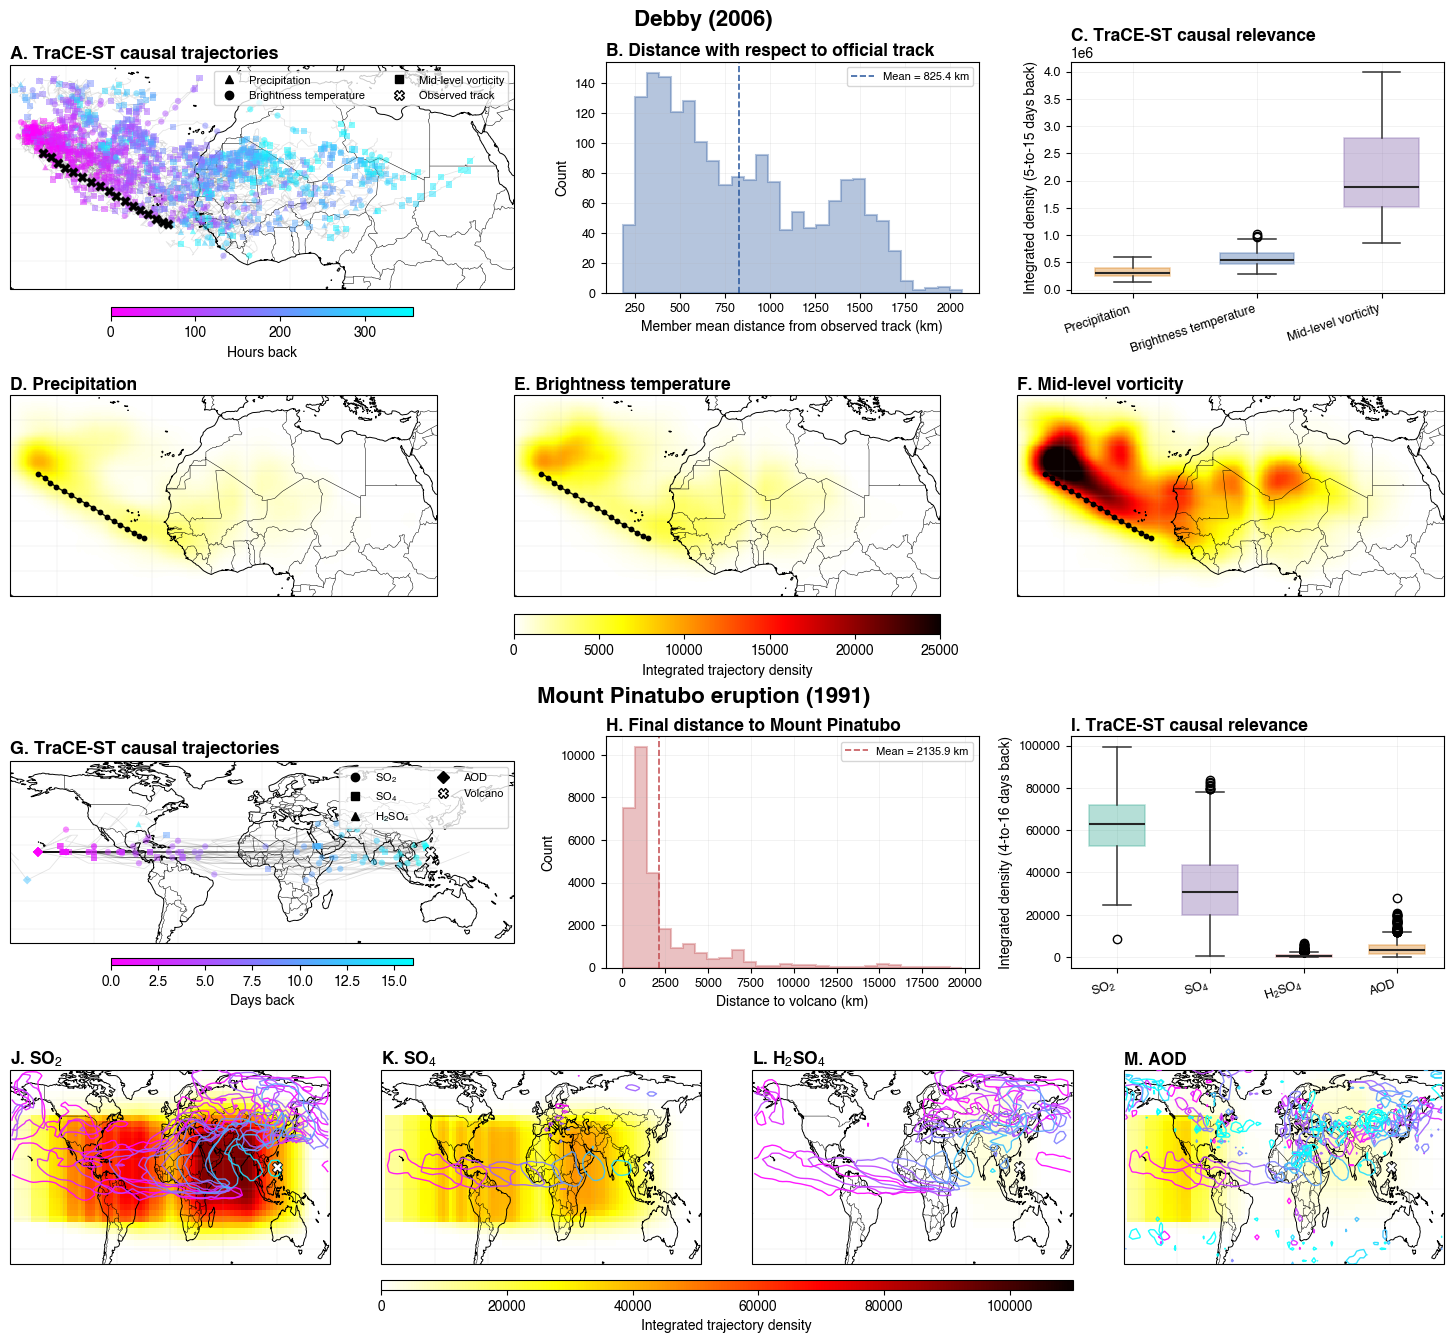

In [249]:
fig3, axes3 = make_fig3_full(
    debby_trial_ids=debby_trial_ids,
    debby_jobs_df=jobs_df_debby,
    debby_members_df=members_df_debby,
    full_data_debby=full_data_debby,
    date_end_debby=date_end_debby,
    extent_debby=extent_debby,
    storm_lon=storm_lon,
    storm_lat=storm_lat,
    storm_hours_back=storm_hours_back,

    pinatubo_trial_ids=pinatubo_trial_ids,
    pinatubo_jobs_df=jobs_df_pinatubo,
    pinatubo_members_df=members_df_pinatubo,
    full_data_pinatubo=full_data_pinatubo,
    date_end_pinatubo=date_end_pinatubo,
    extent_pinatubo=(-180, 180, -50, 80),
    volcano_lon=volcano_lon,
    volcano_lat=volcano_lat,

    max_random_traj=50,
    random_seed=11,
    debby_density_vmax=25000,
    pinatubo_density_vmax=110000,
)

# plt.show()
fig3.savefig("fig3_debby_pinatubo.pdf")

In [252]:
from pypdf import PdfReader, PdfWriter

reader = PdfReader("fig3_debby_pinatubo.pdf")
writer = PdfWriter()

# crop amounts in PDF points (72 pt = 1 inch)
left_crop   = 160
right_crop  = 123
bottom_crop = 90
top_crop    = 100

for page in reader.pages:
    box = page.mediabox

    x0 = float(box.left) + left_crop
    y0 = float(box.bottom) + bottom_crop
    x1 = float(box.right) - right_crop
    y1 = float(box.top) - top_crop

    page.cropbox.lower_left = (x0, y0)
    page.cropbox.upper_right = (x1, y1)
    page.mediabox.lower_left = (x0, y0)
    page.mediabox.upper_right = (x1, y1)

    writer.add_page(page)

with open("fig3_debby_pinatubo_cropped.pdf", "wb") as f:
    writer.write(f)